# Benchmark: Open/Closed Protein Pairs (V2)

Her protein icin **uc mod** calistirir:
1. **Open -> Closed** (open PDB initial, closed PDB target, PDB sekans)
2. **Closed -> Open** (closed PDB initial, open PDB target, PDB sekans)
3. **UniProt Seq** (open PDB initial, closed PDB target, **full UniProt sekans** OF3'e verilir)

Her modda open/closed PDB'lerle TM/RMSD karsilastirilir. Fark: Mode 3'te OF3'e verilen sekans
PDB'den degil, UniProt'tan gelir (eksik loop/terminal farki).

Fixes (V2):
- OF3 model **bir kez** yuklenir (token_mask bug fix)
- Farkli boyutlu yapilar **sequence alignment** ile ortak core uzerinden karsilastirilir
- Chain ID bulunamazsa fallback
- RMSD/TM her zaman **ilk predict edilen yapi** uzerinden (step 1 baseline)

## 1. Environment Setup

In [ ]:
import os, sys, shutil, time, json, warnings
warnings.filterwarnings('ignore')

IN_COLAB = 'google.colab' in sys.modules or os.path.exists('/content')

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)

    if os.path.exists('/content/ANM-openfold3'):
        shutil.rmtree('/content/ANM-openfold3')
    !git clone https://github.com/beratkaskaloglu/ANM-openfold3.git /content/ANM-openfold3

    if not os.path.exists('/content/ANM-openfold3/openfold3-repo'):
        !git clone https://github.com/aqlaboratory/openfold-3.git /content/ANM-openfold3/openfold3-repo
        !pip install -e /content/ANM-openfold3/openfold3-repo -q
    else:
        try:
            import openfold3
        except ImportError:
            !pip install -e /content/ANM-openfold3/openfold3-repo -q

    !pip install -q biopython matplotlib numpy torch pandas requests

    _repo_root = '/content/ANM-openfold3'
else:
    _repo_root = os.path.abspath(os.path.join(os.getcwd(), '..'))

if _repo_root not in sys.path:
    sys.path.insert(0, _repo_root)

if IN_COLAB:
    of3_root = '/content/ANM-openfold3/openfold3-repo'
    if of3_root not in sys.path:
        sys.path.insert(0, of3_root)
    os.makedirs(os.path.expanduser('~/.openfold3'), exist_ok=True)
    from openfold3.entry_points.parameters import (
        download_model_parameters, get_default_checkpoint_dir, DEFAULT_CHECKPOINT_NAME,
    )
    _param_dir = get_default_checkpoint_dir()
    _param_dir.mkdir(parents=True, exist_ok=True)
    download_model_parameters(_param_dir, DEFAULT_CHECKPOINT_NAME, skip_confirmation=True)

print(f'Repo root: {_repo_root}')
print('Environment ready.')

## 2. Benchmark Protein Tablosu

In [ ]:
# ════════════════════════════════════════════════════════════════
#  BENCHMARK PROTEIN PAIRS
#  Sadece dogrulanmis (status='ok') olan ciftler calistirilir.
#  Status:
#    ok    = dogrulandi, calistir
#    skip  = atla (hata/kontrol gerekli)
# ════════════════════════════════════════════════════════════════

BENCHMARK_PAIRS = [
    # (protein_name, uniprot, open_pdb, closed_pdb, chain, status, notes)
    ('Adenylate kinase',       'P69441', '4AKE', '1AKE', 'A', 'ok',   ''),
    ('Maltose-binding',        'P0AEX9', '1OMP', '1ANF', 'A', 'ok',   ''),
    ('Glutamine-binding',      'P0AEQ3', '1GGG', '1WDN', 'A', 'ok',   ''),
    ('Alcohol dehydrogenase',  'P00325', '1LDE', '1LDG', 'A', 'skip', 'kontrol'),
    ('Citrate synthase',       'P00889', '1CTS', '2CTS', 'A', 'ok',   ''),
    ('HIV-1 protease',         'P03367', '1HHP', '1HVR', 'A', 'skip', 'kontrol'),
    ('Lactoferrin',            'P02788', '1LFH', '1LFG', 'A', 'ok',   ''),
    ('GroEL subunit',          'P0A6F5', '1GRL', '1AON', 'A', 'skip', 'kontrol'),
    ('Calmodulin',             'P0DP23', '1CLL', '1CDL', 'A', 'skip', 'kontrol'),
    ('Src kinase',             'P12931', '1Y57', '2SRC', 'A', 'ok',   ''),
    ('PKA-Calpha',             'P05132', '3FJQ', '1SYK', 'A', 'ok',   ''),
    ('T4 lysozyme',            'P00720', '150L', '148L', 'A', 'skip', 'kontrol'),
    ('GGBP',                   'P0AEE5', '2FW0', '2GBP', 'A', 'ok',   'ters kontrol — open/closed swap olabilir'),
    ('RBP',                    'P02741', '1URP', '2DRI', 'A', 'skip', 'hata'),
    ('LAO-binding',            'P02911', '2LAO', '1LST', 'A', 'ok',   ''),
]

# Sadece 'ok' olanlari filtrele
ACTIVE_PAIRS = [(name, uni, op, cl, ch, st, n) for name, uni, op, cl, ch, st, n in BENCHMARK_PAIRS if st == 'ok']

print(f'Toplam {len(BENCHMARK_PAIRS)} protein, {len(ACTIVE_PAIRS)} aktif (ok):')
print(f'{"#":>2} {"Protein":<25} {"UniProt":<10} {"Open":<6} {"Closed":<6} {"Chain"}')
print('-'*70)
for i, (name, uni, op, cl, ch, st, n) in enumerate(ACTIVE_PAIRS, 1):
    print(f'{i:>2} {name:<25} {uni:<10} {op:<6} {cl:<6} {ch}')

## 3. Pipeline Konfigurasyonu

In [ ]:
# ════════════════════════════════════════════════════════════════
#  PIPELINE PARAMETRELERI
# ════════════════════════════════════════════════════════════════

N_STEPS = 15  # benchmark icin step sayisi (hiz icin 15, detay icin 20)

# Selective mixing (V6 best)
SELECTIVE_MIXING     = True
CHANGE_CUTOFF        = 0.15
ALPHA_BASE           = 0.05
ALPHA_MAX            = 0.7
MAPPING              = 'sigmoid'
W_CONNECTIVITY       = 0.5
W_DISTANCE           = 0.5
DIAGONAL_BAND        = 2

# Pipeline
Z_MIXING_ALPHA       = 0.7
COMBINATION_STRATEGY = 'autostop'
N_ANM_MODES          = 20
N_COMBINATIONS       = 20
MAX_COMBO_SIZE       = 3
DF                   = 0.6
DF_MIN               = 0.3
DF_MAX               = 3.0
ANM_CUTOFF           = 15.0
CONTACT_R_CUT        = 10.0
CONTACT_TAU          = 1.5
Z_DIRECTION          = 'plus'

# Composite gate
USE_COMPOSITE_GATE       = True
COMPOSITE_GATE_THRESHOLD = 0.55
GATE_W_CR                = 0.45
GATE_W_PLDDT             = 0.30
GATE_W_RG                = 0.15
GATE_W_PTM               = 0.10

# Hard cutoffs
CONFIDENCE_PTM_CUTOFF     = 0.15
CONFIDENCE_PLDDT_CUTOFF   = 65.0
CONFIDENCE_RG_MAX         = 2.5
CONFIDENCE_RG_MIN         = 0.3
CONFIDENCE_CLASH_REJECT   = True
CONFIDENCE_RMSD_INIT_MAX  = 10.0

# Stall & drift
ALPHA_DECAY           = 0.8
MAX_STALL             = 8
ENABLE_BEST_ROLLBACK  = True
BEST_ROLLBACK_TM_DROP = 0.40
ENABLE_ADAPTIVE_STOP  = True
ADAPTIVE_STOP_WINDOW  = 3
MAX_ROLLBACK_STOP     = 5

# Fallback
ENABLE_FALLBACK           = True
FALLBACK_EXTENDED_ENABLED = True
AUTOSTOP_FALLBACK_LEVELS  = (0, 1, 4, 9)

# Autostop
AUTOSTOP_V_MAGNITUDE = 1.0
AUTOSTOP_N_STEPS     = 5000
AUTOSTOP_BACK_OFF    = 2

# OF3
USE_MSA_SERVER        = True
USE_TEMPLATES         = False
NUM_ROLLOUT_STEPS     = None
NUM_DIFFUSION_SAMPLES = 1

# Converter
DRIVE_DIR = '/content/drive/MyDrive/ANM-openfold3/checkpoints/finetune_msa'
CHECKPOINT_SELECTION = 'best_bf_r'

# Output
if IN_COLAB:
    BASE_SAVE_DIR = '/content/drive/MyDrive/ANM-openfold3/benchmark'
else:
    BASE_SAVE_DIR = os.path.join(_repo_root, 'results', 'benchmark')
os.makedirs(BASE_SAVE_DIR, exist_ok=True)

print(f'N_STEPS={N_STEPS}, selective={SELECTIVE_MIXING}')
print(f'Save dir: {BASE_SAVE_DIR}')

## 4. Helper Fonksiyonlar

In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import requests
matplotlib.rcParams['figure.dpi'] = 120

from Bio.PDB import PDBParser, PDBList
from Bio.SeqUtils import seq1

for mod_name in list(sys.modules.keys()):
    if mod_name.startswith('src'):
        del sys.modules[mod_name]

from src.converter import PairContactConverter
from src.mode_drive import ModeDrivePipeline, ModeDriveConfig, compute_rmsd, tm_score
from src.mode_drive_utils import align_and_trim_ca
from src.of3_diffusion import load_of3_model, OF3ModelCache
from src.autostop_adapter import StructureContext


def fetch_ca(pdb_id: str, chain_id: str):
    """PDB'den CA koordinatlarini ve sekansini cek. Chain fallback var."""
    parser = PDBParser(QUIET=True)
    pdbl = PDBList()
    pdb_file = pdbl.retrieve_pdb_file(pdb_id, pdir='/tmp/pdb_cache', file_format='pdb')
    structure = parser.get_structure(pdb_id, pdb_file)

    chains = [c for c in structure[0].get_chains() if c.id == chain_id]
    if not chains:
        available = [c.id for c in structure[0].get_chains()]
        if available:
            print(f'    WARNING: chain {chain_id} not found in {pdb_id}, using {available[0]} (available: {available})')
            chain = [c for c in structure[0].get_chains() if c.id == available[0]][0]
        else:
            raise ValueError(f'No chains in {pdb_id}')
    else:
        chain = chains[0]

    residues = [r for r in chain if r.get_id()[0] == ' ' and 'CA' in r]
    coords = torch.tensor([r['CA'].get_vector().get_array() for r in residues], dtype=torch.float32)
    sequence = ''.join(seq1(r.get_resname()) for r in residues)
    return coords, sequence


def fetch_uniprot_sequence(uniprot_id: str) -> str:
    """UniProt'tan full protein sekansini cek."""
    url = f'https://rest.uniprot.org/uniprotkb/{uniprot_id}.fasta'
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    lines = resp.text.strip().split('\n')
    seq = ''.join(l.strip() for l in lines if not l.startswith('>'))
    print(f'    UniProt {uniprot_id}: {len(seq)} residues')
    return seq


def make_uniprot_diffusion_wrapper(diffusion_fn, zij_trunk_full, pdb_indices, n_pdb):
    """UniProt modda diffusion_fn'i wrap et.

    Pipeline z_mod [N_pdb, N_pdb, C] uretir. Bunu full UniProt boyutuna
    genisletip diffusion_fn'e ver, sonra donen CA'yi PDB pozisyonlarina indir.
    """
    idx_t = torch.tensor(pdb_indices, dtype=torch.long)
    n_uni = zij_trunk_full.shape[0]

    def _wrapped_diffusion(z_mod_pdb):
        # z_mod_pdb: [N_pdb, N_pdb, C]
        # Full UniProt zij'i kopyala, PDB pozisyonlarini degistir
        z_full = zij_trunk_full.clone()
        z_full[idx_t.unsqueeze(1), idx_t.unsqueeze(0), :] = z_mod_pdb
        # Diffusion (full UniProt boyutunda)
        result = diffusion_fn(z_full)
        # Donen CA'yi PDB pozisyonlarina indir
        if hasattr(result, 'best_ca'):
            # DiffusionResult
            result.best_ca = result.best_ca[idx_t]
            result.all_ca = result.all_ca[:, idx_t, :]
            if result.plddt is not None:
                result.plddt = result.plddt[:, idx_t] if result.plddt.dim() == 2 else result.plddt[idx_t]
        else:
            # Plain tensor [N, 3]
            result = result[idx_t]
        return result

    return _wrapped_diffusion


def load_converter():
    """Converter checkpoint yukle."""
    history_path = os.path.join(DRIVE_DIR, 'history.json')
    best_model_path = os.path.join(DRIVE_DIR, 'best_model.pt')

    if CHECKPOINT_SELECTION == 'best_bf_r' and os.path.exists(history_path):
        with open(history_path) as f:
            history = json.load(f)
        best_bf_r = -1
        best_epoch = -1
        for entry in history:
            bf_r = entry.get('val_bf_pearson', 0)
            if bf_r > best_bf_r:
                best_bf_r = bf_r
                best_epoch = entry['epoch']
        epoch_ckpt = os.path.join(DRIVE_DIR, f'epoch_{best_epoch:04d}.pt')
        ckpt_path = epoch_ckpt if os.path.exists(epoch_ckpt) else best_model_path
        print(f'  Converter: best bf_r={best_bf_r:.4f} epoch={best_epoch}')
    else:
        ckpt_path = best_model_path
    return PairContactConverter(ckpt_path)


def make_config(chain_id):
    """Pipeline config olustur."""
    return ModeDriveConfig(
        n_steps=N_STEPS,
        combination_strategy=COMBINATION_STRATEGY,
        z_mixing_alpha=Z_MIXING_ALPHA,
        n_anm_modes=N_ANM_MODES,
        n_combinations=N_COMBINATIONS,
        max_combo_size=MAX_COMBO_SIZE,
        df=DF, df_min=DF_MIN, df_max=DF_MAX,
        anm_cutoff=ANM_CUTOFF,
        contact_r_cut=CONTACT_R_CUT,
        contact_tau=CONTACT_TAU,
        z_direction=Z_DIRECTION,
        num_diffusion_samples=NUM_DIFFUSION_SAMPLES,
        use_composite_gate=USE_COMPOSITE_GATE,
        composite_gate_threshold=COMPOSITE_GATE_THRESHOLD,
        gate_w_cr=GATE_W_CR,
        gate_w_plddt=GATE_W_PLDDT,
        gate_w_rg=GATE_W_RG,
        gate_w_ptm=GATE_W_PTM,
        confidence_ptm_cutoff=CONFIDENCE_PTM_CUTOFF,
        confidence_plddt_cutoff=CONFIDENCE_PLDDT_CUTOFF,
        confidence_rg_max=CONFIDENCE_RG_MAX,
        confidence_rg_min=CONFIDENCE_RG_MIN,
        confidence_clash_reject=CONFIDENCE_CLASH_REJECT,
        confidence_rmsd_init_max=CONFIDENCE_RMSD_INIT_MAX,
        enable_confidence_fallback=ENABLE_FALLBACK,
        fallback_extended_enabled=FALLBACK_EXTENDED_ENABLED,
        autostop_v_magnitude=AUTOSTOP_V_MAGNITUDE,
        autostop_n_steps=AUTOSTOP_N_STEPS,
        autostop_back_off=AUTOSTOP_BACK_OFF,
        autostop_fallback_levels=AUTOSTOP_FALLBACK_LEVELS,
        autostop_chain_id=chain_id,
        rejected_alpha_decay=ALPHA_DECAY,
        max_consecutive_rejected=MAX_STALL,
        confidence_warmup_steps=0,
        enable_best_rollback=ENABLE_BEST_ROLLBACK,
        best_rollback_tm_drop=BEST_ROLLBACK_TM_DROP,
        enable_adaptive_stop=ENABLE_ADAPTIVE_STOP,
        adaptive_stop_window=ADAPTIVE_STOP_WINDOW,
        selective_mixing=SELECTIVE_MIXING,
        selective_w_connectivity=W_CONNECTIVITY,
        selective_w_distance=W_DISTANCE,
        selective_change_cutoff=CHANGE_CUTOFF,
        selective_alpha_base=ALPHA_BASE,
        selective_alpha_max=ALPHA_MAX,
        selective_mapping=MAPPING,
        selective_diagonal_band=DIAGONAL_BAND,
    )


def run_single_direction(converter, of3_cache, initial_pdb, target_pdb, chain_id, save_dir,
                         mode='directed', uniprot_seq=None):
    """Tek yon icin pipeline calistir.

    Args:
        mode: 'directed' = PDB sekans ile OF3, open/closed karsilastirma
              'uniprot'  = full UniProt sekans ile OF3, open/closed karsilastirma
        uniprot_seq: mode='uniprot' icin UniProt full sequence
    """
    os.makedirs(save_dir, exist_ok=True)
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    # Yapiları yukle
    initial_ca, seq_initial = fetch_ca(initial_pdb, chain_id)
    target_ca_raw, seq_target = fetch_ca(target_pdb, chain_id)
    N_init = initial_ca.shape[0]
    N_target = target_ca_raw.shape[0]

    # Boyut farkliysa sequence alignment ile common core bul
    if N_init != N_target:
        print(f'    SIZE MISMATCH: initial N={N_init}, target N={N_target} -> alignment')
        ca_init_trim, ca_tgt_trim, common_seq, idx_init, idx_target = align_and_trim_ca(
            initial_ca, seq_initial, target_ca_raw, seq_target
        )
        print(f'    Common core: {len(common_seq)} residues')
        target_ca = ca_tgt_trim
        initial_ca_for_comparison = ca_init_trim
        comparison_indices = idx_init
    else:
        target_ca = target_ca_raw
        initial_ca_for_comparison = initial_ca
        comparison_indices = None

    init_tm = tm_score(initial_ca_for_comparison, target_ca)
    init_rmsd = compute_rmsd(initial_ca_for_comparison, target_ca)
    print(f'    N={N_init}, init TM={init_tm:.4f}, init RMSD={init_rmsd:.2f}A')

    # OF3 sequence secimi ve diffusion_fn hazirla
    if mode == 'uniprot' and uniprot_seq is not None:
        of3_sequence = uniprot_seq
        N_of3 = len(of3_sequence)
        print(f'    OF3 sequence: UniProt ({N_of3} res) vs PDB ({N_init} res)')

        # OF3 trunk (full UniProt boyutunda)
        diffusion_fn_full, zij_trunk_full = of3_cache.prepare_sequence(
            sequence=of3_sequence,
            query_name=initial_pdb,
            chain_id=chain_id,
            num_rollout_steps=NUM_ROLLOUT_STEPS,
        )

        if N_of3 != N_init:
            # PDB residue'larin UniProt icindeki pozisyonlarini bul
            from Bio.Align import PairwiseAligner
            _aligner = PairwiseAligner()
            _aligner.mode = 'global'
            _aligner.match_score = 2
            _aligner.mismatch_score = -1
            _aligner.open_gap_score = -5
            _aligner.extend_gap_score = -0.5
            _aln = _aligner.align(of3_sequence, seq_initial)[0]

            pdb_in_uniprot = []
            pos_uni, pos_pdb = 0, 0
            for char_u, char_p in zip(str(_aln[0]), str(_aln[1])):
                gap_u = (char_u == '-')
                gap_p = (char_p == '-')
                if not gap_u and not gap_p:
                    pdb_in_uniprot.append(pos_uni)
                if not gap_u:
                    pos_uni += 1
                if not gap_p:
                    pos_pdb += 1

            print(f'    PDB->UniProt mapping: {len(pdb_in_uniprot)} positions matched')

            # zij_trunk'i PDB boyutuna indir (pipeline icin)
            idx_t = torch.tensor(pdb_in_uniprot, dtype=torch.long)
            zij_trunk = zij_trunk_full[idx_t][:, idx_t, :]  # [N_pdb, N_pdb, C]
            print(f'    zij_trunk trimmed: {zij_trunk.shape}')

            # diffusion_fn'i wrap et: PDB boyutunu UniProt'a genislet, sonra geri indir
            diffusion_fn = make_uniprot_diffusion_wrapper(
                diffusion_fn_full, zij_trunk_full, pdb_in_uniprot, N_init
            )
        else:
            # Ayni boyut — dogrudan kullan
            zij_trunk = zij_trunk_full
            diffusion_fn = diffusion_fn_full
    else:
        of3_sequence = seq_initial
        diffusion_fn, zij_trunk = of3_cache.prepare_sequence(
            sequence=of3_sequence,
            query_name=initial_pdb,
            chain_id=chain_id,
            num_rollout_steps=NUM_ROLLOUT_STEPS,
        )

    # Structure context
    _pdb_file = PDBList().retrieve_pdb_file(initial_pdb, pdir='/tmp/pdb_cache', file_format='pdb')
    structure_ctx = StructureContext.from_pdb(_pdb_file, chain_id=chain_id)

    # Config & pipeline
    cfg = make_config(chain_id)
    pipe = ModeDrivePipeline(
        converter=converter, config=cfg,
        diffusion_fn=diffusion_fn,
        structure_ctx=structure_ctx,
    )

    # Run
    coords_ca = initial_ca.clone()
    z_current = zij_trunk.clone()
    orig_alpha = Z_MIXING_ALPHA
    current_alpha = orig_alpha
    consecutive_rejected = 0
    coords_best = initial_ca.clone()
    z_best = zij_trunk.clone()
    best_target_tm = init_tm
    rollback_count = 0

    trajectory_coords = [initial_ca.clone()]
    step_tms_target = [init_tm]
    step_rmsds_target = [init_rmsd]
    step_tms_init = []
    step_rmsds_init = []
    step_tms_source = [1.0]      # TM to source/initial structure (starts at 1.0)
    step_rmsds_source = [0.0]    # RMSD to source/initial structure (starts at 0.0)
    first_predicted_ca = None
    step_metrics = []

    t0 = time.time()

    for step_idx in range(N_STEPS):
        cfg.z_mixing_alpha = current_alpha
        sr = pipe.step_with_fallback(
            coords_ca, initial_ca, z_current,
            prev_rmsd=0.0,
            target_coords=target_ca if comparison_indices is None else None,
            step_idx=step_idx,
        )

        accepted = not sr.rejected
        if sr.rg_ratio is not None and sr.rg_ratio > CONFIDENCE_RG_MAX:
            accepted = False
        if sr.has_clash and CONFIDENCE_CLASH_REJECT:
            accepted = False
        if sr.rmsd > CONFIDENCE_RMSD_INIT_MAX:
            accepted = False

        # Karsilastirma icin predicted CA'yi trim et
        predicted_ca_cmp = sr.new_ca[comparison_indices] if comparison_indices is not None else sr.new_ca

        cur_tm = tm_score(predicted_ca_cmp, target_ca)
        cur_rmsd = compute_rmsd(predicted_ca_cmp, target_ca)
        cur_tm_source = tm_score(predicted_ca_cmp, initial_ca_for_comparison)
        cur_rmsd_source = compute_rmsd(predicted_ca_cmp, initial_ca_for_comparison)

        # ilk predict baseline
        if first_predicted_ca is None and accepted:
            first_predicted_ca = predicted_ca_cmp.clone()

        if first_predicted_ca is not None:
            tm_vs_first = tm_score(predicted_ca_cmp, first_predicted_ca)
            rmsd_vs_first = compute_rmsd(predicted_ca_cmp, first_predicted_ca)
        else:
            tm_vs_first = 1.0
            rmsd_vs_first = 0.0

        plddt_mean = float(sr.plddt.mean()) if sr.plddt is not None else None

        m = {
            'step': step_idx + 1,
            'accepted': accepted,
            'tm_to_target': cur_tm,
            'rmsd_to_target': cur_rmsd,
            'tm_to_first': tm_vs_first,
            'rmsd_to_first': rmsd_vs_first,
            'rmsd_to_init': sr.rmsd,
            'ptm': sr.ptm,
            'plddt_mean': plddt_mean,
            'contact_recon': sr.contact_recon,
            'rg_ratio': sr.rg_ratio,
            'fallback_level': sr.fallback_level,
            'alpha_used': current_alpha,
        }
        step_metrics.append(m)

        tag = 'ACC' if accepted else 'REJ'
        print(
            f'      [{step_idx+1:>2}/{N_STEPS}] {tag} '
            f'TM_tgt={cur_tm:.3f} RMSD_tgt={cur_rmsd:.1f} '
            f'TM_1st={tm_vs_first:.3f} FL={sr.fallback_level}'
        )

        if accepted:
            trajectory_coords.append(sr.new_ca.clone())
            step_tms_target.append(cur_tm)
            step_rmsds_target.append(cur_rmsd)
            step_tms_init.append(tm_vs_first)
            step_rmsds_init.append(rmsd_vs_first)
            step_tms_source.append(cur_tm_source)
            step_rmsds_source.append(cur_rmsd_source)
            coords_ca = sr.new_ca
            z_current = sr.z_modified
            consecutive_rejected = 0
            current_alpha = orig_alpha

            # Best tracking
            if cur_tm > best_target_tm:
                best_target_tm = cur_tm
                coords_best = sr.new_ca.clone()
                z_best = sr.z_modified.clone()
            elif best_target_tm > 0 and cur_tm < best_target_tm * (1.0 - BEST_ROLLBACK_TM_DROP):
                coords_ca = coords_best.clone()
                z_current = z_best.clone()
                rollback_count += 1
                if rollback_count >= MAX_ROLLBACK_STOP:
                    print(f'      STOP: {rollback_count} rollback')
                    break
        else:
            consecutive_rejected += 1
            if ALPHA_DECAY < 1.0:
                current_alpha = max(0.02, current_alpha * ALPHA_DECAY)
            if MAX_STALL > 0 and consecutive_rejected >= MAX_STALL:
                print(f'      STALL: {consecutive_rejected} rejected')
                break

    wall = time.time() - t0

    # Final
    final_tm = step_tms_target[-1]
    final_rmsd = step_rmsds_target[-1]
    n_accepted = len(trajectory_coords) - 1

    result = {
        'init_tm': init_tm,
        'init_rmsd': init_rmsd,
        'best_tm': best_target_tm,
        'final_tm': final_tm,
        'final_rmsd': final_rmsd,
        'delta_tm': best_target_tm - init_tm,
        'n_accepted': n_accepted,
        'n_steps_run': len(step_metrics),
        'rollbacks': rollback_count,
        'wall_time': wall,
        'step_tms_target': step_tms_target,
        'step_rmsds_target': step_rmsds_target,
        'step_tms_init': step_tms_init,
        'step_rmsds_init': step_rmsds_init,
        'step_tms_source': step_tms_source,
        'step_rmsds_source': step_rmsds_source,
        'step_metrics': step_metrics,
        'trajectory_coords': trajectory_coords,
        'mode': mode,
    }

    print(f'    => init_TM={init_tm:.4f} best_TM={best_target_tm:.4f} delta={best_target_tm-init_tm:+.4f} ({wall:.0f}s)')
    return result


print('Helper fonksiyonlar tanimlandi.')

## 5. Converter + OF3 Model Yukle (bir kez)

In [ ]:
converter = load_converter()
print('Converter ready.')

# OF3 model BIR KEZ yukle (token_mask bug fix)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
of3_cache = load_of3_model(
    device=device,
    num_samples=NUM_DIFFUSION_SAMPLES,
    use_msa_server=USE_MSA_SERVER,
    use_templates=USE_TEMPLATES,
)
print('OF3 model cached — her protein icin prepare_sequence() kullanilacak.')

## 6. Benchmark Dongusu: 3 Mod (Open->Closed, Closed->Open, UniProt Seq)

In [ ]:
# ════════════════════════════════════════════════════════════════
#  ANA BENCHMARK DONGUSU
#  Her protein icin 3 mod:
#    [A] open  -> closed  (PDB sekans, directed)
#    [B] closed -> open   (PDB sekans, directed)
#    [C] UniProt sekans   (full UniProt seq -> OF3, open initial, closed target)
#  Her protein bittikten sonra TUM plotlar + pickle kaydeder (crash korumasi)
# ════════════════════════════════════════════════════════════════

import pickle
from collections import defaultdict
from matplotlib.lines import Line2D

# ── Pickle'dan devam et (varsa) ──
_pkl_resume = os.path.join(BASE_SAVE_DIR, 'benchmark_results.pkl')
all_results = []
_completed_keys = set()
if os.path.exists(_pkl_resume):
    with open(_pkl_resume, 'rb') as f:
        _loaded = pickle.load(f)
    for entry in _loaded:
        res = {k: v for k, v in entry.items() if k not in ('protein', 'direction', 'mode')}
        all_results.append((entry['protein'], entry['direction'], entry['mode'], res))
        _completed_keys.add((entry['protein'], entry['direction']))
    print(f'RESUME: {len(all_results)} onceki run yuklendi, devam ediliyor...')
    for n, d, dt, _ in all_results:
        print(f'  [SKIP] {n} / {d} ({dt})')

    # ── Eksik source metrics'i hesapla (eski pickle'lar icin) ──
    _needs_source = [i for i, (n, d, dt, res) in enumerate(all_results)
                     if dt in ('open->closed', 'closed->open')
                     and (not res.get('step_tms_source') or len(res.get('step_tms_source', [])) < 2)]
    if _needs_source:
        print(f'\n  {len(_needs_source)} run icin source metrics eksik, hesaplaniyor...')
        # Protein -> (open_ca, closed_ca) cache
        _ca_cache = {}
        for _pair in ACTIVE_PAIRS:
            _pname, _, _opdb, _cpdb, _ch, _, _ = _pair
            if _pname not in _ca_cache:
                try:
                    _oca, _ = fetch_ca(_opdb, _ch)
                    _cca, _ = fetch_ca(_cpdb, _ch)
                    _ca_cache[_pname] = (_oca, _cca)
                except Exception as _e:
                    print(f'    WARNING: {_pname} CA fetch failed: {_e}')

        for _idx in _needs_source:
            _n, _d, _dt, _res = all_results[_idx]
            _traj = _res.get('trajectory_coords', [])
            if len(_traj) < 2:
                print(f'    [SKIP] {_n}/{_d}: no trajectory_coords ({len(_traj)} frames)')
                continue
            if _n not in _ca_cache:
                print(f'    [SKIP] {_n}/{_d}: no CA cache')
                continue
            _oca, _cca = _ca_cache[_n]
            # source = initial structure (open for O->C, closed for C->O)
            _source_ca = _oca if _dt == 'open->closed' else _cca
            import torch as _th
            _tms_src, _rmsds_src = [], []
            for _ca in _traj:
                if not isinstance(_ca, _th.Tensor):
                    _ca = _th.tensor(_ca, dtype=_th.float32)
                try:
                    # Boyut farkliysa trim
                    if _ca.shape[0] != _source_ca.shape[0]:
                        _min_n = min(_ca.shape[0], _source_ca.shape[0])
                        _ca_t = _ca[:_min_n]
                        _src_t = _source_ca[:_min_n]
                    else:
                        _ca_t = _ca
                        _src_t = _source_ca
                    _tms_src.append(tm_score(_ca_t, _src_t))
                    _rmsds_src.append(compute_rmsd(_ca_t, _src_t))
                except Exception:
                    _tms_src.append(1.0)
                    _rmsds_src.append(0.0)
            _res['step_tms_source'] = _tms_src
            _res['step_rmsds_source'] = _rmsds_src
            print(f'    [OK] {_n}/{_d}: {len(_tms_src)} steps, src_tm[0]={_tms_src[0]:.3f} -> src_tm[-1]={_tms_src[-1]:.3f}')
        print()
else:
    print('Yeni benchmark basliyor (onceki kayit yok)')

def _ensure_source_metrics(all_results):
    """Eski pickle'lardan yuklenen sonuclarda step_tms_source yoksa trajectory_coords'tan hesapla."""
    import torch
    for i, (n, d, dt, res) in enumerate(all_results):
        has_src = res.get('step_tms_source') and len(res['step_tms_source']) > 1
        if has_src:
            print(f'    [SOURCE OK] {n}/{d}: step_tms_source has {len(res["step_tms_source"])} pts')
            continue
        traj = res.get('trajectory_coords', [])
        print(f'    [SOURCE MISSING] {n}/{d}: has_src={has_src}, traj_len={len(traj)}, keys={[k for k in res.keys() if "source" in k or "traj" in k]}')
        if len(traj) < 2:
            print(f'    [SKIP] no trajectory_coords to recompute from')
            continue
        try:
            src_ca = traj[0]
            if not isinstance(src_ca, torch.Tensor):
                src_ca = torch.tensor(src_ca, dtype=torch.float32)
            tms_src, rmsds_src = [], []
            for ca in traj:
                if not isinstance(ca, torch.Tensor):
                    ca = torch.tensor(ca, dtype=torch.float32)
                if ca.shape[0] != src_ca.shape[0]:
                    tms_src.append(1.0)
                    rmsds_src.append(0.0)
                    continue
                tms_src.append(tm_score(ca, src_ca))
                rmsds_src.append(compute_rmsd(ca, src_ca))
            res['step_tms_source'] = tms_src
            res['step_rmsds_source'] = rmsds_src
            print(f'    [RECOMPUTE OK] {n}/{d}: {len(tms_src)} steps, first={tms_src[0]:.3f}, last={tms_src[-1]:.3f}')
        except Exception as e:
            print(f'    [RECOMPUTE FAIL] {n}/{d}: {e}')
            import traceback; traceback.print_exc()


def _save_all_plots(all_results, pair_idx, name):
    """Her protein sonrasi tum plotlari bas + pickle kaydet."""
    if not all_results:
        return

    # ── Pickle kaydet ──
    _sd = []
    for n, d, dt, res in all_results:
        entry = {k: v for k, v in res.items()}
        entry['protein'], entry['direction'], entry['mode'] = n, d, dt
        if 'trajectory_coords' in entry:
            entry['trajectory_coords'] = [
                c.cpu().numpy() if hasattr(c, 'cpu') else c for c in entry['trajectory_coords']
            ]
        _sd.append(entry)
    _pkl = os.path.join(BASE_SAVE_DIR, 'benchmark_results.pkl')
    with open(_pkl, 'wb') as f:
        pickle.dump(_sd, f)
    print(f'    [SAVE] Pickle -> {_pkl}')

    prefix = f'interim_{pair_idx+1:02d}'
    color_map = {'open->closed': '#e74c3c', 'closed->open': '#3498db', 'uniprot': '#27ae60'}
    n_runs = len(all_results)
    dir_types = [dt for _, _, dt, _ in all_results]

    # ── Fig 1: TM Trajectory ──
    n_cols = min(3, n_runs)
    n_rows = max(1, (n_runs + n_cols - 1) // n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 3.5*n_rows), squeeze=False)
    axes_flat = axes.flatten()
    for idx, (n, d, dt, res) in enumerate(all_results):
        ax = axes_flat[idx]
        tms = res['step_tms_target']
        color = color_map.get(dt, '#7f8c8d')
        ax.plot(range(len(tms)), tms, 'o-', color=color, markersize=4, linewidth=1.5)
        ax.axhline(y=res['init_tm'], color='gray', linestyle='--', alpha=0.4)
        ax.axhline(y=1.0, color='green', linestyle=':', alpha=0.3)
        ax.set_xlabel('Frame', fontsize=8)
        ax.set_ylabel('TM to target', fontsize=8)
        ax.set_title(f'{n}\n{d}', fontsize=9)
        ax.set_ylim(max(0, min(tms)-0.05), min(1.0, max(tms)+0.05))
        ax.grid(True, alpha=0.2)
        ax.text(0.95, 0.05, f'delta={res["delta_tm"]:+.3f}',
               transform=ax.transAxes, fontsize=7, ha='right', va='bottom',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    for idx in range(n_runs, len(axes_flat)):
        axes_flat[idx].set_visible(False)
    plt.suptitle(f'TM Trajectories ({pair_idx+1} proteins done)', fontsize=12)
    plt.tight_layout()
    p = os.path.join(BASE_SAVE_DIR, f'{prefix}_fig01_tm_trajectories.png')
    fig.savefig(p, dpi=150, bbox_inches='tight'); plt.show(); plt.close(fig)
    print(f'    [PLOT] {p}')

    # ── Fig 2: Delta TM Bar ──
    fig, ax = plt.subplots(figsize=(12, max(5, n_runs*0.4)))
    labels = [f'{n}\n{d}' for n, d, _, _ in all_results]
    deltas = [r['delta_tm'] for _, _, _, r in all_results]
    colors_bar = ['#2ecc71' if d > 0.01 else ('#e74c3c' if d < -0.01 else '#95a5a6') for d in deltas]
    y_pos = np.arange(len(labels))
    ax.barh(y_pos, deltas, color=colors_bar, edgecolor='black', linewidth=0.5, alpha=0.8)
    ax.set_yticks(y_pos); ax.set_yticklabels(labels, fontsize=7)
    ax.set_xlabel('Delta TM (best - initial)', fontsize=11)
    ax.set_title('Mode-Drive Improvement: Delta TM per Run', fontsize=12)
    ax.axvline(x=0, color='black', linewidth=0.8); ax.grid(True, alpha=0.2, axis='x')
    for i, d in enumerate(deltas):
        x_off = 0.005 if d >= 0 else -0.005
        ax.text(d + x_off, i, f'{d:+.3f}', va='center', ha='left' if d >= 0 else 'right', fontsize=7)
    plt.tight_layout()
    p = os.path.join(BASE_SAVE_DIR, f'{prefix}_fig02_delta_tm_bar.png')
    fig.savefig(p, dpi=150, bbox_inches='tight'); plt.show(); plt.close(fig)
    print(f'    [PLOT] {p}')

    # ── Fig 3: Init vs Best TM Scatter ──
    fig, ax = plt.subplots(figsize=(8, 8))
    init_tms = [r['init_tm'] for _, _, _, r in all_results]
    best_tms = [r['best_tm'] for _, _, _, r in all_results]
    for i in range(n_runs):
        c = color_map.get(dir_types[i], '#7f8c8d')
        m = 'o' if dir_types[i] == 'open->closed' else ('s' if dir_types[i] == 'closed->open' else '^')
        ax.scatter(init_tms[i], best_tms[i], c=c, marker=m, s=120, edgecolors='black', linewidths=0.5, zorder=5)
        ax.annotate(f'{all_results[i][0][:12]}', (init_tms[i], best_tms[i]),
                   textcoords='offset points', xytext=(5, 5), fontsize=6, alpha=0.8)
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='No change')
    ax.set_xlabel('Initial TM to Target', fontsize=11)
    ax.set_ylabel('Best TM to Target', fontsize=11)
    ax.set_title('Init vs Best TM (above diagonal = improvement)', fontsize=12)
    ax.set_xlim(0.3, 1.0); ax.set_ylim(0.3, 1.0); ax.set_aspect('equal'); ax.grid(True, alpha=0.2)
    legend_el = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=10, label='open->closed'),
        Line2D([0], [0], marker='s', color='w', markerfacecolor='#3498db', markersize=10, label='closed->open'),
        Line2D([0], [0], marker='^', color='w', markerfacecolor='#27ae60', markersize=10, label='uniprot'),
    ]
    ax.legend(handles=legend_el, loc='lower right')
    plt.tight_layout()
    p = os.path.join(BASE_SAVE_DIR, f'{prefix}_fig03_init_vs_best_scatter.png')
    fig.savefig(p, dpi=150, bbox_inches='tight'); plt.show(); plt.close(fig)
    print(f'    [PLOT] {p}')

    # ── Fig 4: Direction Comparison ──
    protein_results = defaultdict(dict)
    for n, d, dt, res in all_results:
        protein_results[n][dt] = res
    both_dirs = {k: v for k, v in protein_results.items() if 'open->closed' in v and 'closed->open' in v}
    if both_dirs:
        fig, ax = plt.subplots(figsize=(10, max(5, len(both_dirs)*0.6)))
        proteins = list(both_dirs.keys())
        y_pos_d = np.arange(len(proteins)); width = 0.35
        deltas_oc = [both_dirs[pp]['open->closed']['delta_tm'] for pp in proteins]
        deltas_co = [both_dirs[pp]['closed->open']['delta_tm'] for pp in proteins]
        ax.barh(y_pos_d - width/2, deltas_oc, width, label='Open->Closed', color='#e74c3c', alpha=0.7, edgecolor='black', linewidth=0.5)
        ax.barh(y_pos_d + width/2, deltas_co, width, label='Closed->Open', color='#3498db', alpha=0.7, edgecolor='black', linewidth=0.5)
        ax.set_yticks(y_pos_d); ax.set_yticklabels(proteins, fontsize=9)
        ax.set_xlabel('Delta TM', fontsize=11); ax.set_title('Direction Comparison', fontsize=12)
        ax.axvline(x=0, color='black', linewidth=0.8); ax.legend(loc='lower right'); ax.grid(True, alpha=0.2, axis='x')
        plt.tight_layout()
        p = os.path.join(BASE_SAVE_DIR, f'{prefix}_fig04_direction_comparison.png')
        fig.savefig(p, dpi=150, bbox_inches='tight'); plt.show(); plt.close(fig)
        print(f'    [PLOT] {p}')

    # ── Fig 5: RMSD Reduction ──
    fig, ax = plt.subplots(figsize=(8, 8))
    init_rmsds = [r['init_rmsd'] for _, _, _, r in all_results]
    final_rmsds = [r['final_rmsd'] for _, _, _, r in all_results]
    for i in range(n_runs):
        c = color_map.get(dir_types[i], '#7f8c8d')
        ax.scatter(init_rmsds[i], final_rmsds[i], c=c, s=120, edgecolors='black', linewidths=0.5, zorder=5)
        ax.annotate(f'{all_results[i][0][:12]}', (init_rmsds[i], final_rmsds[i]),
                   textcoords='offset points', xytext=(5, 5), fontsize=6, alpha=0.8)
    max_r = max(max(init_rmsds), max(final_rmsds)) + 1
    ax.plot([0, max_r], [0, max_r], 'k--', alpha=0.3, label='No change')
    ax.set_xlabel('Initial RMSD to Target (A)', fontsize=11)
    ax.set_ylabel('Final RMSD to Target (A)', fontsize=11)
    ax.set_title('RMSD Reduction (below diagonal = improvement)', fontsize=12)
    ax.set_aspect('equal'); ax.grid(True, alpha=0.2)
    legend_el2 = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=10, label='open->closed'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#3498db', markersize=10, label='closed->open'),
    ]
    ax.legend(handles=legend_el2, loc='upper left')
    plt.tight_layout()
    p = os.path.join(BASE_SAVE_DIR, f'{prefix}_fig05_rmsd_reduction.png')
    fig.savefig(p, dpi=150, bbox_inches='tight'); plt.show(); plt.close(fig)
    print(f'    [PLOT] {p}')

    # ── Fig 6: Confidence vs TM Improvement ──
    fig, axes_c = plt.subplots(1, 3, figsize=(15, 5))
    avg_ptms, avg_plddts, avg_crs, delta_tms_c = [], [], [], []
    for _, _, _, res in all_results:
        acc_steps = [m for m in res['step_metrics'] if m['accepted']]
        if not acc_steps:
            avg_ptms.append(None); avg_plddts.append(None); avg_crs.append(None)
        else:
            ptms = [m['ptm'] for m in acc_steps if m['ptm'] is not None]
            plddts = [m['plddt_mean'] for m in acc_steps if m['plddt_mean'] is not None]
            crs = [m['contact_recon'] for m in acc_steps if m['contact_recon'] is not None]
            avg_ptms.append(np.mean(ptms) if ptms else None)
            avg_plddts.append(np.mean(plddts) if plddts else None)
            avg_crs.append(np.mean(crs) if crs else None)
        delta_tms_c.append(res['delta_tm'])
    valid = [(pp, d) for pp, d in zip(avg_ptms, delta_tms_c) if pp is not None]
    if valid:
        xs, ys = zip(*valid)
        axes_c[0].scatter(xs, ys, c='#9b59b6', s=80, edgecolors='black', linewidths=0.5)
    axes_c[0].set_xlabel('Avg pTM'); axes_c[0].set_ylabel('Delta TM'); axes_c[0].set_title('pTM vs Improvement')
    axes_c[0].grid(True, alpha=0.2); axes_c[0].axhline(y=0, color='black', linewidth=0.5)
    valid = [(pp, d) for pp, d in zip(avg_plddts, delta_tms_c) if pp is not None]
    if valid:
        xs, ys = zip(*valid)
        axes_c[1].scatter(xs, ys, c='#e67e22', s=80, edgecolors='black', linewidths=0.5)
    axes_c[1].set_xlabel('Avg pLDDT'); axes_c[1].set_ylabel('Delta TM'); axes_c[1].set_title('pLDDT vs Improvement')
    axes_c[1].grid(True, alpha=0.2); axes_c[1].axhline(y=0, color='black', linewidth=0.5)
    valid = [(pp, d) for pp, d in zip(avg_crs, delta_tms_c) if pp is not None]
    if valid:
        xs, ys = zip(*valid)
        axes_c[2].scatter(xs, ys, c='#1abc9c', s=80, edgecolors='black', linewidths=0.5)
    axes_c[2].set_xlabel('Avg cR'); axes_c[2].set_ylabel('Delta TM'); axes_c[2].set_title('cR vs Improvement')
    axes_c[2].grid(True, alpha=0.2); axes_c[2].axhline(y=0, color='black', linewidth=0.5)
    plt.suptitle('Confidence Metrics vs TM Improvement', fontsize=12)
    plt.tight_layout()
    p = os.path.join(BASE_SAVE_DIR, f'{prefix}_fig06_confidence_vs_improvement.png')
    fig.savefig(p, dpi=150, bbox_inches='tight'); plt.show(); plt.close(fig)
    print(f'    [PLOT] {p}')

    # ── Fig 7: 2D Scatter TM_init vs TM_target & RMSD ──
    fig, axes_2d = plt.subplots(1, 2, figsize=(14, 6))
    ax = axes_2d[0]
    for n, d, dt, res in all_results:
        tms_target = res['step_tms_target'][1:]
        tms_init = res['step_tms_init']
        if not tms_init: continue
        n_pts = min(len(tms_target), len(tms_init))
        c = color_map.get(dt, '#7f8c8d')
        ax.scatter(tms_init[:n_pts], tms_target[:n_pts], c=c, s=40, alpha=0.5, edgecolors='none')
        ax.scatter(tms_init[n_pts-1], tms_target[n_pts-1], c=c, s=120, edgecolors='black', linewidths=1, zorder=10, marker='D')
    ax.set_xlabel('TM vs First Predicted', fontsize=10); ax.set_ylabel('TM vs Target', fontsize=10)
    ax.set_title('TM_initial vs TM_target (diamonds = final)', fontsize=11)
    ax.grid(True, alpha=0.2); ax.set_xlim(0.3, 1.05); ax.set_ylim(0.3, 1.05)
    legend_2d = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=8, label='open->closed'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#3498db', markersize=8, label='closed->open'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#27ae60', markersize=8, label='uniprot'),
    ]
    ax.legend(handles=legend_2d, loc='lower left')
    ax = axes_2d[1]
    for n, d, dt, res in all_results:
        rmsds_target = res['step_rmsds_target'][1:]
        rmsds_init = res['step_rmsds_init']
        if not rmsds_init: continue
        n_pts = min(len(rmsds_target), len(rmsds_init))
        c = color_map.get(dt, '#7f8c8d')
        ax.scatter(rmsds_init[:n_pts], rmsds_target[:n_pts], c=c, s=40, alpha=0.5, edgecolors='none')
        ax.scatter(rmsds_init[n_pts-1], rmsds_target[n_pts-1], c=c, s=120, edgecolors='black', linewidths=1, zorder=10, marker='D')
    ax.set_xlabel('RMSD vs First Predicted (A)', fontsize=10); ax.set_ylabel('RMSD vs Target (A)', fontsize=10)
    ax.set_title('RMSD_initial vs RMSD_target (diamonds = final)', fontsize=11)
    ax.grid(True, alpha=0.2); ax.legend(handles=legend_2d, loc='upper left')
    plt.suptitle('Step-wise 2D: Exploration vs Progress', fontsize=12, y=1.02)
    plt.tight_layout()
    p = os.path.join(BASE_SAVE_DIR, f'{prefix}_fig07_2d_tm_rmsd_scatter.png')
    fig.savefig(p, dpi=150, bbox_inches='tight'); plt.show(); plt.close(fig)
    print(f'    [PLOT] {p}')

    # Eski pickle'dan yuklenen sonuclarda source metrics yoksa hesapla
    _ensure_source_metrics(all_results)

    # ── Fig 8: Conformational Landscape per Step (TM to Open vs TM to Closed & RMSD) ──
    # Her step'in koordinatlari icin: source=initial yapi, target=hedef yapi
    # open->closed: source=open, target=closed => X=TM_source(open), Y=TM_target(closed)
    # closed->open: source=closed, target=open => X=TM_target(open), Y=TM_source(closed)
    fig, axes_land = plt.subplots(1, 2, figsize=(14, 6))

    # Panel 1: TM to Open vs TM to Closed
    ax = axes_land[0]
    _plotted = 0
    for n, d, dt, res in all_results:
        tms_tgt = res['step_tms_target']
        tms_src = res.get('step_tms_source', [])
        print(f'    [FIG8 DEBUG] {n}/{d} dt={dt}: tms_tgt={len(tms_tgt)}, tms_src={len(tms_src)}')
        if not tms_src or len(tms_src) < 2:
            print(f'    [FIG8 SKIP] {n}/{d}: no source data')
            continue
        n_pts = min(len(tms_tgt), len(tms_src))
        c = color_map.get(dt, '#7f8c8d')
        if dt == 'open->closed':
            x_vals = tms_src[:n_pts]   # TM to open (source)
            y_vals = tms_tgt[:n_pts]   # TM to closed (target)
        elif dt == 'closed->open':
            x_vals = tms_tgt[:n_pts]   # TM to open (target)
            y_vals = tms_src[:n_pts]   # TM to closed (source)
        else:
            continue  # uniprot skip for now
        ax.scatter(x_vals, y_vals, c=c, s=30, alpha=0.4, edgecolors='none')
        ax.scatter(x_vals[0], y_vals[0], c=c, s=150, edgecolors='black', linewidths=1.5, marker='o', zorder=10)
        ax.scatter(x_vals[-1], y_vals[-1], c=c, s=150, edgecolors='black', linewidths=1.5, marker='D', zorder=10)
        ax.annotate(f'{n[:10]}', (x_vals[-1], y_vals[-1]),
                   textcoords='offset points', xytext=(5, 5), fontsize=5, alpha=0.7)
    ax.set_xlabel('TM to Open', fontsize=11); ax.set_ylabel('TM to Closed', fontsize=11)
    ax.set_title('Conformational Landscape (TM)\n(circle=start, diamond=final)', fontsize=11)
    ax.set_xlim(0.2, 1.05); ax.set_ylim(0.2, 1.05); ax.set_aspect('equal'); ax.grid(True, alpha=0.2)
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.2)
    legend_land = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=8, label='open->closed'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#3498db', markersize=8, label='closed->open'),
    ]
    ax.legend(handles=legend_land, loc='upper right')

    # Panel 2: RMSD to Open vs RMSD to Closed
    ax = axes_land[1]
    for n, d, dt, res in all_results:
        rmsds_tgt = res['step_rmsds_target']
        rmsds_src = res.get('step_rmsds_source', [])
        if not rmsds_src:
            continue
        n_pts = min(len(rmsds_tgt), len(rmsds_src))
        c = color_map.get(dt, '#7f8c8d')
        if dt == 'open->closed':
            x_vals = rmsds_src[:n_pts]   # RMSD to open (source)
            y_vals = rmsds_tgt[:n_pts]   # RMSD to closed (target)
        elif dt == 'closed->open':
            x_vals = rmsds_tgt[:n_pts]   # RMSD to open (target)
            y_vals = rmsds_src[:n_pts]   # RMSD to closed (source)
        else:
            continue
        ax.scatter(x_vals, y_vals, c=c, s=30, alpha=0.4, edgecolors='none')
        ax.scatter(x_vals[0], y_vals[0], c=c, s=150, edgecolors='black', linewidths=1.5, marker='o', zorder=10)
        ax.scatter(x_vals[-1], y_vals[-1], c=c, s=150, edgecolors='black', linewidths=1.5, marker='D', zorder=10)
        ax.annotate(f'{n[:10]}', (x_vals[-1], y_vals[-1]),
                   textcoords='offset points', xytext=(5, 5), fontsize=5, alpha=0.7)
    ax.set_xlabel('RMSD to Open (A)', fontsize=11); ax.set_ylabel('RMSD to Closed (A)', fontsize=11)
    ax.set_title('Conformational Landscape (RMSD)\n(circle=start, diamond=final)', fontsize=11)
    ax.set_aspect('equal'); ax.grid(True, alpha=0.2)
    max_rmsd = 1.0
    for _, _, dt, res in all_results:
        if dt in ('open->closed', 'closed->open'):
            max_rmsd = max(max_rmsd, max(res['step_rmsds_target'] + res.get('step_rmsds_source', [0])))
    ax.plot([0, max_rmsd+1], [0, max_rmsd+1], 'k--', alpha=0.2)
    ax.legend(handles=legend_land, loc='upper right')

    plt.suptitle('Step-wise Conformational Landscape: Open vs Closed', fontsize=12, y=1.02)
    plt.tight_layout()
    p = os.path.join(BASE_SAVE_DIR, f'{prefix}_fig08_landscape_open_closed.png')
    fig.savefig(p, dpi=150, bbox_inches='tight'); plt.show(); plt.close(fig)
    print(f'    [PLOT] {p}')


for pair_idx, (name, uniprot, open_pdb, closed_pdb, chain, status, notes) in enumerate(ACTIVE_PAIRS):
    print(f'\n{"="*80}')
    print(f'  [{pair_idx+1}/{len(ACTIVE_PAIRS)}] {name} ({uniprot})')
    print(f'  Open={open_pdb}, Closed={closed_pdb}, Chain={chain}')
    print(f'{"="*80}')

    pair_dir = os.path.join(BASE_SAVE_DIR, f'{pair_idx+1:02d}_{name.replace(" ", "_")}')

    # UniProt sekansini bir kez cek (mode C icin)
    try:
        uni_seq = fetch_uniprot_sequence(uniprot)
    except Exception as e:
        print(f'    WARNING: UniProt fetch failed ({e}), mode C skip')
        uni_seq = None

    # ── [A] Open -> Closed (PDB sekans) ──
    _key_a = (name, f'{open_pdb}->{closed_pdb}')
    if _key_a in _completed_keys:
        print(f'\n  [A] Open -> Closed ({open_pdb} -> {closed_pdb})  ** SKIP (zaten tamamlandi) **')
    else:
      print(f'\n  [A] Open -> Closed ({open_pdb} -> {closed_pdb})')
      try:
          dir_a = os.path.join(pair_dir, f'{open_pdb}_to_{closed_pdb}')
          res_a = run_single_direction(converter, of3_cache, open_pdb, closed_pdb, chain, dir_a, mode='directed')
          if res_a is not None:
              all_results.append((name, f'{open_pdb}->{closed_pdb}', 'open->closed', res_a))
      except Exception as e:
          print(f'    HATA: {e}')
          import traceback; traceback.print_exc()

    # ── [B] Closed -> Open (PDB sekans) ──
    _key_b = (name, f'{closed_pdb}->{open_pdb}')
    if _key_b in _completed_keys:
        print(f'\n  [B] Closed -> Open ({closed_pdb} -> {open_pdb})  ** SKIP (zaten tamamlandi) **')
    else:
      print(f'\n  [B] Closed -> Open ({closed_pdb} -> {open_pdb})')
      try:
          dir_b = os.path.join(pair_dir, f'{closed_pdb}_to_{open_pdb}')
          res_b = run_single_direction(converter, of3_cache, closed_pdb, open_pdb, chain, dir_b, mode='directed')
          if res_b is not None:
              all_results.append((name, f'{closed_pdb}->{open_pdb}', 'closed->open', res_b))
      except Exception as e:
          print(f'    HATA: {e}')
          import traceback; traceback.print_exc()

    # ── [C] UniProt Seq (open initial, closed target, full UniProt sekans) ──
    _key_c = (name, f'{uniprot}(uni)')
    if _key_c in _completed_keys:
        print(f'\n  [C] UniProt Seq  ** SKIP (zaten tamamlandi) **')
    elif uni_seq is not None:
        print(f'\n  [C] UniProt Seq ({uniprot}, {open_pdb} -> {closed_pdb})')
        try:
            dir_c = os.path.join(pair_dir, f'{open_pdb}_uniprot')
            res_c = run_single_direction(
                converter, of3_cache, open_pdb, closed_pdb, chain, dir_c,
                mode='uniprot', uniprot_seq=uni_seq,
            )
            if res_c is not None:
                all_results.append((name, f'{uniprot}(uni)', 'uniprot', res_c))
        except Exception as e:
            print(f'    HATA: {e}')
            import traceback; traceback.print_exc()

    # ── Her protein sonrasi: TUM plotlar + pickle kaydet ──
    _save_all_plots(all_results, pair_idx, name)

print(f'\n\n{"="*80}')
print(f'BENCHMARK TAMAMLANDI: {len(all_results)} basarili run / {len(ACTIVE_PAIRS)*3} toplam')
print(f'{"="*80}')


## 6b. Koordinatlari ve Metrikleri Kaydet

In [ ]:
# ════════════════════════════════════════════════════════════════
#  KOORDINATLARI + METRIKLERI DISKE KAYDET
#  Kernel crash/restart sonrasi plot celllerini tekrar calistirmak icin
# ════════════════════════════════════════════════════════════════
import pickle

save_data = []
for name, direction, dir_type, res in all_results:
    entry = {
        'protein': name,
        'direction': direction,
        'mode': dir_type,
        'init_tm': res['init_tm'],
        'init_rmsd': res['init_rmsd'],
        'best_tm': res['best_tm'],
        'final_tm': res['final_tm'],
        'final_rmsd': res['final_rmsd'],
        'delta_tm': res['delta_tm'],
        'n_accepted': res['n_accepted'],
        'n_steps_run': res['n_steps_run'],
        'rollbacks': res['rollbacks'],
        'wall_time': res['wall_time'],
        'step_tms_target': res['step_tms_target'],
        'step_rmsds_target': res['step_rmsds_target'],
        'step_tms_init': res['step_tms_init'],
        'step_rmsds_init': res['step_rmsds_init'],
        'step_metrics': res['step_metrics'],
        # Koordinatlar: torch tensor -> numpy (pickle uyumlulugu)
        'trajectory_coords': [c.cpu().numpy() if hasattr(c, 'cpu') else c for c in res['trajectory_coords']],
    }
    save_data.append(entry)

pkl_path = os.path.join(BASE_SAVE_DIR, 'benchmark_results.pkl')
with open(pkl_path, 'wb') as f:
    pickle.dump(save_data, f)
print(f'Saved {len(save_data)} runs -> {pkl_path}')
print(f'  Her run icinde trajectory_coords: list of [N, 3] numpy arrays')

# Ayrica her protein icin best koordinati ayri .npy olarak kaydet
coords_dir = os.path.join(BASE_SAVE_DIR, 'coords')
os.makedirs(coords_dir, exist_ok=True)
for entry in save_data:
    tag = f"{entry['protein'].replace(' ', '_')}_{entry['mode']}"
    # Son accepted koordinat = best trajectory noktasi
    best_coords = entry['trajectory_coords'][-1]  # [N, 3]
    np.save(os.path.join(coords_dir, f'{tag}_best.npy'), best_coords)
    # Initial koordinat
    np.save(os.path.join(coords_dir, f'{tag}_initial.npy'), entry['trajectory_coords'][0])

print(f'  Per-protein .npy files -> {coords_dir}/')
print(f'  Dosyalar: {len(os.listdir(coords_dir))}')

## 7. Sonuc Tablosu

## 6c. (Opsiyonel) Pickle'dan Yukle — kernel restart sonrasi plot icin

In [ ]:
# ════════════════════════════════════════════════════════════════
#  PICKLE'DAN YUKLE (sadece kernel restart sonrasi, benchmark tekrar calistirmadan)
#  Bu cell'i sadece plot yapmak istiyorsaniz calistirin.
#  Benchmark dongusunu calistirdiysa zaten all_results doludur, ATLAYIN.
# ════════════════════════════════════════════════════════════════

import pickle, numpy as np, os

# all_results zaten varsa yukleme
if 'all_results' not in dir() or not all_results:
    _pkl = os.path.join(BASE_SAVE_DIR, 'benchmark_results.pkl')
    if os.path.exists(_pkl):
        with open(_pkl, 'rb') as f:
            _loaded = pickle.load(f)
        # pickle formatini all_results tuple formatina cevir
        all_results = []
        for entry in _loaded:
            res = {k: v for k, v in entry.items() if k not in ('protein', 'direction', 'mode')}
            # numpy -> list (plot uyumlulugu, trajectory_coords numpy kalabilir)
            all_results.append((entry['protein'], entry['direction'], entry['mode'], res))
        print(f'Pickle yuklenedi: {len(all_results)} run from {_pkl}')
    else:
        print(f'Pickle bulunamadi: {_pkl}')
        print('Once benchmark dongusunu (cell 6) calistirin.')
else:
    print(f'all_results zaten dolu ({len(all_results)} run), pickle yuklenmedi.')

In [ ]:
# ════════════════════════════════════════════════════════════════
#  OZET TABLO
# ════════════════════════════════════════════════════════════════

summary_rows = []
for name, direction, dir_type, res in all_results:
    row = {
        'Protein': name,
        'Direction': direction,
        'Mode': dir_type,
        'Init TM': f"{res['init_tm']:.4f}",
        'Best TM': f"{res['best_tm']:.4f}",
        'Final TM': f"{res['final_tm']:.4f}",
        'Delta TM': f"{res['delta_tm']:+.4f}",
        'Init RMSD': f"{res['init_rmsd']:.2f}",
        'Final RMSD': f"{res['final_rmsd']:.2f}",
        'Accepted': f"{res['n_accepted']}/{res['n_steps_run']}",
        'Rollbacks': res['rollbacks'],
        'Time(s)': f"{res['wall_time']:.0f}",
    }
    if res['step_rmsds_init']:
        row['RMSD_vs_1st'] = f"{res['step_rmsds_init'][-1]:.2f}"
    else:
        row['RMSD_vs_1st'] = '-'
    summary_rows.append(row)

df_summary = pd.DataFrame(summary_rows)
print(df_summary.to_string(index=False))

# Save
csv_path = os.path.join(BASE_SAVE_DIR, 'benchmark_summary.csv')
df_summary.to_csv(csv_path, index=False)
print(f'\nSaved: {csv_path}')

# Mod bazinda ortalamalar
for mode_name in ['open->closed', 'closed->open', 'uniprot']:
    mode_results = [r for _, _, dt, r in all_results if dt == mode_name]
    if mode_results:
        avg_d = np.mean([r['delta_tm'] for r in mode_results])
        avg_b = np.mean([r['best_tm'] for r in mode_results])
        pos = sum(1 for r in mode_results if r['delta_tm'] > 0.01)
        print(f'\n[{mode_name}] n={len(mode_results)}, avg_delta={avg_d:+.4f}, avg_best={avg_b:.4f}, pozitif={pos}/{len(mode_results)}')

## 8. Figure: TM Trajectory per Protein

In [ ]:
# ═════════════════════════════════════════════════════════���══════
#  TM TRAJECTORY: Her protein icin step-by-step TM to target
# ════════════���═══════════════════════════════════════════════════

if all_results:
    n_runs = len(all_results)
    n_cols = 3
    n_rows = (n_runs + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 3.5*n_rows))
    axes_flat = np.array(axes).flatten() if n_runs > 1 else [axes]

    color_map = {'open->closed': '#e74c3c', 'closed->open': '#3498db', 'uniprot': '#27ae60'}

    for idx, (name, direction, dir_type, res) in enumerate(all_results):
        ax = axes_flat[idx]
        tms = res['step_tms_target']
        xs = list(range(len(tms)))
        color = color_map.get(dir_type, '#7f8c8d')
        ax.plot(xs, tms, 'o-', color=color, markersize=4, linewidth=1.5)
        ax.axhline(y=res['init_tm'], color='gray', linestyle='--', alpha=0.4)
        ax.axhline(y=1.0, color='green', linestyle=':', alpha=0.3)
        ax.set_xlabel('Frame', fontsize=8)
        ax.set_ylabel('TM to target', fontsize=8)
        ax.set_title(f'{name}\n{direction}', fontsize=9)
        ax.set_ylim(max(0, min(tms)-0.05), min(1.0, max(tms)+0.05))
        ax.grid(True, alpha=0.2)
        ax.text(0.95, 0.05, f'delta={res["delta_tm"]:+.3f}',
               transform=ax.transAxes, fontsize=7, ha='right', va='bottom',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    for idx in range(n_runs, len(axes_flat)):
        axes_flat[idx].set_visible(False)

    plt.suptitle('TM to Target per Step (red=O->C, blue=C->O, green=UniProt)', fontsize=12)
    plt.tight_layout()
    fig_path = os.path.join(BASE_SAVE_DIR, 'fig_01_tm_trajectories.png')
    fig.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fig_path}')

## 9. Figure: Delta TM Bar Chart

In [ ]:
# ════════════════════════════════════════════════════════════════
#  DELTA TM BAR CHART: Her run icin init -> best iyilesme
# ════════════════════════════════════════════════════════════════

if all_results:
    fig, ax = plt.subplots(figsize=(12, max(5, len(all_results)*0.4)))

    labels = [f'{name}\n{direction}' for name, direction, _, _ in all_results]
    deltas = [r['delta_tm'] for _, _, _, r in all_results]
    colors = ['#2ecc71' if d > 0.01 else ('#e74c3c' if d < -0.01 else '#95a5a6') for d in deltas]

    y_pos = np.arange(len(labels))
    ax.barh(y_pos, deltas, color=colors, edgecolor='black', linewidth=0.5, alpha=0.8)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=7)
    ax.set_xlabel('Delta TM (best - initial)', fontsize=11)
    ax.set_title('Mode-Drive Improvement: Delta TM per Run', fontsize=12)
    ax.axvline(x=0, color='black', linewidth=0.8)
    ax.grid(True, alpha=0.2, axis='x')

    # Annotate values
    for i, d in enumerate(deltas):
        x_offset = 0.005 if d >= 0 else -0.005
        ha = 'left' if d >= 0 else 'right'
        ax.text(d + x_offset, i, f'{d:+.3f}', va='center', ha=ha, fontsize=7)

    plt.tight_layout()
    fig_path = os.path.join(BASE_SAVE_DIR, 'fig_02_delta_tm_bar.png')
    fig.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fig_path}')

## 10. Figure: Init vs Best TM Scatter

In [ ]:
# ════════════════════════════════════════════════════════════════
#  SCATTER: Init TM vs Best TM
# ════════════════════════════════════════════════════════════════

if all_results:
    fig, ax = plt.subplots(figsize=(8, 8))

    init_tms = [r['init_tm'] for _, _, _, r in all_results]
    best_tms = [r['best_tm'] for _, _, _, r in all_results]
    dir_types = [dt for _, _, dt, _ in all_results]

    colors = ['#e74c3c' if dt == 'open->closed' else '#3498db' for dt in dir_types]
    markers = ['o' if dt == 'open->closed' else 's' for dt in dir_types]

    for i in range(len(all_results)):
        ax.scatter(init_tms[i], best_tms[i], c=colors[i], marker=markers[i],
                  s=120, edgecolors='black', linewidths=0.5, zorder=5)

    # Diagonal (no improvement)
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='No change')

    # Annotate
    for i, (name, direction, _, _) in enumerate(all_results):
        ax.annotate(f'{name[:12]}', (init_tms[i], best_tms[i]),
                   textcoords='offset points', xytext=(5, 5), fontsize=6, alpha=0.8)

    ax.set_xlabel('Initial TM to Target', fontsize=11)
    ax.set_ylabel('Best TM to Target', fontsize=11)
    ax.set_title('Mode-Drive: Initial vs Best TM\n(above diagonal = improvement)', fontsize=12)
    ax.set_xlim(0.3, 1.0)
    ax.set_ylim(0.3, 1.0)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)

    # Legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c',
               markersize=10, label='open->closed'),
        Line2D([0], [0], marker='s', color='w', markerfacecolor='#3498db',
               markersize=10, label='closed->open'),
    ]
    ax.legend(handles=legend_elements, loc='lower right')

    plt.tight_layout()
    fig_path = os.path.join(BASE_SAVE_DIR, 'fig_03_init_vs_best_scatter.png')
    fig.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fig_path}')

## 11. Figure: Open vs Closed Direction Comparison

In [ ]:
# ════════════════════════════════════════════════════════════════
#  YON KARSILASTIRMASI: Ayni protein, farkli yon
# ════════════════════════════════════════════════════════════════

if all_results:
    # Protein bazinda gruplama
    from collections import defaultdict
    protein_results = defaultdict(dict)
    for name, direction, dir_type, res in all_results:
        protein_results[name][dir_type] = res

    # Sadece her iki yonu de olan proteinler
    both_dirs = {k: v for k, v in protein_results.items() if 'open->closed' in v and 'closed->open' in v}

    if both_dirs:
        fig, ax = plt.subplots(figsize=(10, max(5, len(both_dirs)*0.6)))

        proteins = list(both_dirs.keys())
        y_pos = np.arange(len(proteins))
        width = 0.35

        deltas_oc = [both_dirs[p]['open->closed']['delta_tm'] for p in proteins]
        deltas_co = [both_dirs[p]['closed->open']['delta_tm'] for p in proteins]

        ax.barh(y_pos - width/2, deltas_oc, width, label='Open->Closed',
               color='#e74c3c', alpha=0.7, edgecolor='black', linewidth=0.5)
        ax.barh(y_pos + width/2, deltas_co, width, label='Closed->Open',
               color='#3498db', alpha=0.7, edgecolor='black', linewidth=0.5)

        ax.set_yticks(y_pos)
        ax.set_yticklabels(proteins, fontsize=9)
        ax.set_xlabel('Delta TM (best - initial)', fontsize=11)
        ax.set_title('Direction Comparison: Open->Closed vs Closed->Open', fontsize=12)
        ax.axvline(x=0, color='black', linewidth=0.8)
        ax.legend(loc='lower right')
        ax.grid(True, alpha=0.2, axis='x')

        plt.tight_layout()
        fig_path = os.path.join(BASE_SAVE_DIR, 'fig_04_direction_comparison.png')
        fig.savefig(fig_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'Saved: {fig_path}')
    else:
        print('Iki yonu de olan protein yok.')

## 12. Figure: RMSD Reduction

In [ ]:
# ════════════════════════════════════════════════════════════════
#  RMSD AZALMA: init RMSD vs final RMSD to target
# ════════════════════════════════════════════════════════════════

if all_results:
    fig, ax = plt.subplots(figsize=(8, 8))

    init_rmsds = [r['init_rmsd'] for _, _, _, r in all_results]
    final_rmsds = [r['final_rmsd'] for _, _, _, r in all_results]
    dir_types = [dt for _, _, dt, _ in all_results]

    colors = ['#e74c3c' if dt == 'open->closed' else '#3498db' for dt in dir_types]

    for i in range(len(all_results)):
        ax.scatter(init_rmsds[i], final_rmsds[i], c=colors[i],
                  s=120, edgecolors='black', linewidths=0.5, zorder=5)

    # Diagonal
    max_r = max(max(init_rmsds), max(final_rmsds)) + 1
    ax.plot([0, max_r], [0, max_r], 'k--', alpha=0.3, label='No change')

    for i, (name, direction, _, _) in enumerate(all_results):
        ax.annotate(f'{name[:12]}', (init_rmsds[i], final_rmsds[i]),
                   textcoords='offset points', xytext=(5, 5), fontsize=6, alpha=0.8)

    ax.set_xlabel('Initial RMSD to Target (A)', fontsize=11)
    ax.set_ylabel('Final RMSD to Target (A)', fontsize=11)
    ax.set_title('RMSD Reduction\n(below diagonal = improvement)', fontsize=12)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)

    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c',
               markersize=10, label='open->closed'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#3498db',
               markersize=10, label='closed->open'),
    ]
    ax.legend(handles=legend_elements, loc='upper left')

    plt.tight_layout()
    fig_path = os.path.join(BASE_SAVE_DIR, 'fig_05_rmsd_reduction.png')
    fig.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fig_path}')

## 12b. 2D Scatter: TM_init vs TM_target & RMSD_init vs RMSD_target

In [ ]:
# ════════════════════════════════════════════════════════════════
#  2D SCATTER: TM_initial vs TM_target  &  RMSD_initial vs RMSD_target
#  "initial" = ilk predict edilen yapiya gore (step 1 baseline)
#  "target"  = hedef yapiya gore
# ════════════════════════════════════════════════════════════════

color_map = {'open->closed': '#e74c3c', 'closed->open': '#3498db', 'uniprot': '#27ae60'}

if all_results:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # ── Panel 1: TM_init vs TM_target (her step) ──
    ax = axes[0]
    for name, direction, dir_type, res in all_results:
        tms_target = res['step_tms_target'][1:]
        tms_init = res['step_tms_init']
        if not tms_init:
            continue
        n_pts = min(len(tms_target), len(tms_init))
        color = color_map.get(dir_type, '#7f8c8d')
        ax.scatter(tms_init[:n_pts], tms_target[:n_pts],
                  c=color, s=40, alpha=0.5, edgecolors='none')
        ax.scatter(tms_init[n_pts-1], tms_target[n_pts-1],
                  c=color, s=120, edgecolors='black', linewidths=1, zorder=10, marker='D')

    ax.set_xlabel('TM vs First Predicted (similarity to step-1)', fontsize=10)
    ax.set_ylabel('TM vs Target (progress toward goal)', fontsize=10)
    ax.set_title('TM_initial vs TM_target\n(diamonds = final step)', fontsize=11)
    ax.grid(True, alpha=0.2)
    ax.set_xlim(0.3, 1.05)
    ax.set_ylim(0.3, 1.05)

    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=8, label='open->closed'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#3498db', markersize=8, label='closed->open'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#27ae60', markersize=8, label='uniprot'),
    ]
    ax.legend(handles=legend_elements, loc='lower left')

    # ── Panel 2: RMSD_init vs RMSD_target (her step) ──
    ax = axes[1]
    for name, direction, dir_type, res in all_results:
        rmsds_target = res['step_rmsds_target'][1:]
        rmsds_init = res['step_rmsds_init']
        if not rmsds_init:
            continue
        n_pts = min(len(rmsds_target), len(rmsds_init))
        color = color_map.get(dir_type, '#7f8c8d')
        ax.scatter(rmsds_init[:n_pts], rmsds_target[:n_pts],
                  c=color, s=40, alpha=0.5, edgecolors='none')
        ax.scatter(rmsds_init[n_pts-1], rmsds_target[n_pts-1],
                  c=color, s=120, edgecolors='black', linewidths=1, zorder=10, marker='D')

    ax.set_xlabel('RMSD vs First Predicted (A)', fontsize=10)
    ax.set_ylabel('RMSD vs Target (A)', fontsize=10)
    ax.set_title('RMSD_initial vs RMSD_target\n(diamonds = final step)', fontsize=11)
    ax.grid(True, alpha=0.2)
    ax.legend(handles=legend_elements, loc='upper left')

    plt.suptitle('Step-wise 2D: Exploration (vs 1st predict) vs Progress (vs target)', fontsize=12, y=1.02)
    plt.tight_layout()
    fig_path = os.path.join(BASE_SAVE_DIR, 'fig_07_2d_tm_rmsd_scatter.png')
    fig.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fig_path}')

## 12c. Conformational Landscape: TM to Open vs Closed & RMSD to Open vs Closed (per step)

In [ ]:
# ════════════════════════════════════════════════════════════════
#  CONFORMATIONAL LANDSCAPE PER STEP: TM & RMSD to Open vs Closed
#  Her step'in yapisi icin source (initial) ve target yapisina TM/RMSD
#  open->closed: source=open, target=closed
#  closed->open: source=closed, target=open
# ════════════════════════════════════════════════════════════════

from matplotlib.lines import Line2D
color_map = {'open->closed': '#e74c3c', 'closed->open': '#3498db', 'uniprot': '#27ae60'}

# Eski pickle'dan yuklenen sonuclarda source metrics yoksa hesapla
if all_results:
    for _i, (_n, _d, _dt, _res) in enumerate(all_results):
        if not _res.get('step_tms_source'):
            _traj = _res.get('trajectory_coords', [])
            if len(_traj) >= 2:
                import torch as _th
                _src = _traj[0]
                if not isinstance(_src, _th.Tensor):
                    _src = _th.tensor(_src, dtype=_th.float32)
                _ts, _rs = [], []
                for _ca in _traj:
                    if not isinstance(_ca, _th.Tensor):
                        _ca = _th.tensor(_ca, dtype=_th.float32)
                    if _ca.shape[0] == _src.shape[0]:
                        _ts.append(tm_score(_ca, _src))
                        _rs.append(compute_rmsd(_ca, _src))
                if _ts:
                    _res['step_tms_source'] = _ts
                    _res['step_rmsds_source'] = _rs

if all_results:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Panel 1: TM to Open vs TM to Closed
    ax = axes[0]
    for name, direction, dir_type, res in all_results:
        tms_tgt = res['step_tms_target']
        tms_src = res.get('step_tms_source', [])
        if not tms_src:
            continue
        n_pts = min(len(tms_tgt), len(tms_src))
        c = color_map.get(dir_type, '#7f8c8d')
        if dir_type == 'open->closed':
            x_vals = tms_src[:n_pts]   # TM to open (source)
            y_vals = tms_tgt[:n_pts]   # TM to closed (target)
        elif dir_type == 'closed->open':
            x_vals = tms_tgt[:n_pts]   # TM to open (target)
            y_vals = tms_src[:n_pts]   # TM to closed (source)
        else:
            continue
        ax.scatter(x_vals, y_vals, c=c, s=30, alpha=0.4, edgecolors='none')
        # Start = circle, End = diamond
        ax.scatter(x_vals[0], y_vals[0], c=c, s=150, edgecolors='black',
                  linewidths=1.5, marker='o', zorder=10)
        ax.scatter(x_vals[-1], y_vals[-1], c=c, s=150, edgecolors='black',
                  linewidths=1.5, marker='D', zorder=10)
        ax.annotate(f'{name[:12]}', (x_vals[-1], y_vals[-1]),
                   textcoords='offset points', xytext=(5, 5), fontsize=6, alpha=0.8)

    ax.set_xlabel('TM to Open', fontsize=11)
    ax.set_ylabel('TM to Closed', fontsize=11)
    ax.set_title('Conformational Landscape (TM)\n(circle=start, diamond=final)', fontsize=11)
    ax.set_xlim(0.2, 1.05); ax.set_ylim(0.2, 1.05)
    ax.set_aspect('equal'); ax.grid(True, alpha=0.2)
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.2)
    legend_el = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=10, label='open->closed'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#3498db', markersize=10, label='closed->open'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='black', markersize=8, label='start'),
        Line2D([0], [0], marker='D', color='w', markerfacecolor='black', markersize=8, label='final'),
    ]
    ax.legend(handles=legend_el, loc='upper right')

    # Panel 2: RMSD to Open vs RMSD to Closed
    ax = axes[1]
    for name, direction, dir_type, res in all_results:
        rmsds_tgt = res['step_rmsds_target']
        rmsds_src = res.get('step_rmsds_source', [])
        if not rmsds_src:
            continue
        n_pts = min(len(rmsds_tgt), len(rmsds_src))
        c = color_map.get(dir_type, '#7f8c8d')
        if dir_type == 'open->closed':
            x_vals = rmsds_src[:n_pts]   # RMSD to open (source)
            y_vals = rmsds_tgt[:n_pts]   # RMSD to closed (target)
        elif dir_type == 'closed->open':
            x_vals = rmsds_tgt[:n_pts]   # RMSD to open (target)
            y_vals = rmsds_src[:n_pts]   # RMSD to closed (source)
        else:
            continue
        ax.scatter(x_vals, y_vals, c=c, s=30, alpha=0.4, edgecolors='none')
        ax.scatter(x_vals[0], y_vals[0], c=c, s=150, edgecolors='black',
                  linewidths=1.5, marker='o', zorder=10)
        ax.scatter(x_vals[-1], y_vals[-1], c=c, s=150, edgecolors='black',
                  linewidths=1.5, marker='D', zorder=10)
        ax.annotate(f'{name[:12]}', (x_vals[-1], y_vals[-1]),
                   textcoords='offset points', xytext=(5, 5), fontsize=6, alpha=0.8)

    ax.set_xlabel('RMSD to Open (A)', fontsize=11)
    ax.set_ylabel('RMSD to Closed (A)', fontsize=11)
    ax.set_title('Conformational Landscape (RMSD)\n(circle=start, diamond=final)', fontsize=11)
    ax.set_aspect('equal'); ax.grid(True, alpha=0.2)
    max_rmsd = 1.0
    for _, _, dt, res in all_results:
        if dt in ('open->closed', 'closed->open'):
            max_rmsd = max(max_rmsd, max(res['step_rmsds_target'] + res.get('step_rmsds_source', [0])))
    ax.plot([0, max_rmsd+1], [0, max_rmsd+1], 'k--', alpha=0.2)
    ax.legend(handles=legend_el, loc='upper right')

    plt.suptitle('Step-wise Conformational Landscape: Open vs Closed', fontsize=12, y=1.02)
    plt.tight_layout()
    fig_path = os.path.join(BASE_SAVE_DIR, 'fig_08_landscape_open_closed.png')
    fig.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fig_path}')


## 13. Figure: Confidence vs TM Improvement

In [ ]:
# ════════════════════════════════════════════════════════════════
#  CONFIDENCE vs TM IMPROVEMENT korelasyonu
# ════════════════════════════════════════════════════════════════

if all_results:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Her run'in ortalama confidence metrics
    avg_ptms = []
    avg_plddts = []
    avg_crs = []
    delta_tms = []

    for _, _, _, res in all_results:
        acc_steps = [m for m in res['step_metrics'] if m['accepted']]
        if not acc_steps:
            avg_ptms.append(None)
            avg_plddts.append(None)
            avg_crs.append(None)
        else:
            ptms = [m['ptm'] for m in acc_steps if m['ptm'] is not None]
            plddts = [m['plddt_mean'] for m in acc_steps if m['plddt_mean'] is not None]
            crs = [m['contact_recon'] for m in acc_steps if m['contact_recon'] is not None]
            avg_ptms.append(np.mean(ptms) if ptms else None)
            avg_plddts.append(np.mean(plddts) if plddts else None)
            avg_crs.append(np.mean(crs) if crs else None)
        delta_tms.append(res['delta_tm'])

    # pTM vs delta_TM
    valid = [(p, d) for p, d in zip(avg_ptms, delta_tms) if p is not None]
    if valid:
        xs, ys = zip(*valid)
        axes[0].scatter(xs, ys, c='#9b59b6', s=80, edgecolors='black', linewidths=0.5)
        axes[0].set_xlabel('Avg pTM')
        axes[0].set_ylabel('Delta TM')
        axes[0].set_title('pTM vs Improvement')
        axes[0].grid(True, alpha=0.2)
        axes[0].axhline(y=0, color='black', linewidth=0.5)

    # pLDDT vs delta_TM
    valid = [(p, d) for p, d in zip(avg_plddts, delta_tms) if p is not None]
    if valid:
        xs, ys = zip(*valid)
        axes[1].scatter(xs, ys, c='#e67e22', s=80, edgecolors='black', linewidths=0.5)
        axes[1].set_xlabel('Avg pLDDT')
        axes[1].set_ylabel('Delta TM')
        axes[1].set_title('pLDDT vs Improvement')
        axes[1].grid(True, alpha=0.2)
        axes[1].axhline(y=0, color='black', linewidth=0.5)

    # cR vs delta_TM
    valid = [(p, d) for p, d in zip(avg_crs, delta_tms) if p is not None]
    if valid:
        xs, ys = zip(*valid)
        axes[2].scatter(xs, ys, c='#1abc9c', s=80, edgecolors='black', linewidths=0.5)
        axes[2].set_xlabel('Avg Contact Recon (cR)')
        axes[2].set_ylabel('Delta TM')
        axes[2].set_title('cR vs Improvement')
        axes[2].grid(True, alpha=0.2)
        axes[2].axhline(y=0, color='black', linewidth=0.5)

    plt.suptitle('Confidence Metrics vs TM Improvement', fontsize=12)
    plt.tight_layout()
    fig_path = os.path.join(BASE_SAVE_DIR, 'fig_06_confidence_vs_improvement.png')
    fig.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fig_path}')

## 14. Final Ozet

In [ ]:
# ════════════════════════════════════════════════════════════════
#  FINAL OZET
# ════════════════════════════════════════════════════════════════

print('='*80)
print('  BENCHMARK OZET')
print('='*80)

if all_results:
    n_total = len(all_results)
    n_positive = sum(1 for _, _, _, r in all_results if r['delta_tm'] > 0.01)
    n_negative = sum(1 for _, _, _, r in all_results if r['delta_tm'] < -0.01)
    n_neutral = n_total - n_positive - n_negative

    avg_delta = np.mean([r['delta_tm'] for _, _, _, r in all_results])
    max_delta = max(all_results, key=lambda x: x[3]['delta_tm'])
    min_delta = min(all_results, key=lambda x: x[3]['delta_tm'])

    # Open->Closed vs Closed->Open ortalama
    oc_deltas = [r['delta_tm'] for _, _, dt, r in all_results if dt == 'open->closed']
    co_deltas = [r['delta_tm'] for _, _, dt, r in all_results if dt == 'closed->open']

    print(f'\n  Toplam run: {n_total}')
    print(f'  Pozitif (delta>0.01): {n_positive} ({100*n_positive/n_total:.0f}%)')
    print(f'  Notr    (|delta|<=0.01): {n_neutral}')
    print(f'  Negatif (delta<-0.01): {n_negative}')
    print(f'\n  Ortalama delta TM: {avg_delta:+.4f}')
    print(f'  En iyi:  {max_delta[0]} {max_delta[1]} delta={max_delta[3]["delta_tm"]:+.4f}')
    print(f'  En kotu: {min_delta[0]} {min_delta[1]} delta={min_delta[3]["delta_tm"]:+.4f}')

    if oc_deltas:
        print(f'\n  Open->Closed ortalama delta: {np.mean(oc_deltas):+.4f} (n={len(oc_deltas)})')
    if co_deltas:
        print(f'  Closed->Open ortalama delta: {np.mean(co_deltas):+.4f} (n={len(co_deltas)})')

    total_time = sum(r['wall_time'] for _, _, _, r in all_results)
    print(f'\n  Toplam sure: {total_time:.0f}s ({total_time/60:.1f}min)')
    print(f'  Ortalama run suresi: {total_time/n_total:.0f}s')

print(f'\n  Config: selective={SELECTIVE_MIXING} cutoff={CHANGE_CUTOFF} base={ALPHA_BASE} max={ALPHA_MAX}')
print(f'          mapping={MAPPING} band={DIAGONAL_BAND} alpha={Z_MIXING_ALPHA}')

print(f'\n  Kaydedilen dosyalar ({BASE_SAVE_DIR}):')
for f in sorted(os.listdir(BASE_SAVE_DIR)):
    fpath = os.path.join(BASE_SAVE_DIR, f)
    if os.path.isfile(fpath):
        size_kb = os.path.getsize(fpath) / 1024
        print(f'    {f} ({size_kb:.0f} KB)')
print('='*80)

## 15. Experimental PDB Konformasyonlari: RCSB'den Tum Yapilari Cek

Her protein icin ayni UniProt ID'ye ait **tum experimental PDB yapilarini** RCSB API'den ceker,
CA koordinatlarini indirir ve open/closed target'lara gore TM skorlarini hesaplar.
Sonra scatter plot'ta gri nokta olarak gosterir — pipeline ciktisi bunlarin arasinda nerede duruyor?

In [ ]:
# ════════════════════════════════════════════════════════════════
#  RCSB API: UniProt ID'den tum PDB yapilarini cek
#  Her yapi icin open & closed target'a TM skoru hesapla
# ════════════════════════════════════════════════════════════════

def fetch_pdb_ids_for_uniprot(uniprot_id, max_results=50):
    """RCSB Search API ile UniProt ID'ye ait tum PDB ID'lerini cek."""
    query = {
        "query": {
            "type": "terminal",
            "service": "text",
            "parameters": {
                "attribute": "rcsb_polymer_entity_container_identifiers.reference_sequence_identifiers.database_accession",
                "operator": "exact_match",
                "value": uniprot_id
            }
        },
        "request_options": {
            "return_all_hits": True,
            "results_content_type": ["experimental"]
        },
        "return_type": "entry"
    }
    resp = requests.post(
        'https://search.rcsb.org/rcsbsearch/v2/query',
        json=query, timeout=30
    )
    if resp.status_code != 200:
        return []
    data = resp.json()
    pdb_ids = [hit['identifier'] for hit in data.get('result_set', [])]
    return pdb_ids[:max_results]


def compute_experimental_tms(active_pairs, max_pdbs_per_protein=30):
    """Her protein icin tum experimental PDB yapilarini cek ve TM hesapla.

    Returns:
        dict: {protein_name: [
            {'pdb_id': '...', 'tm_to_open': float, 'tm_to_closed': float, 'n_res': int},
            ...
        ]}
    """
    from src.mode_drive import tm_score, compute_rmsd
    from src.mode_drive_utils import align_and_trim_ca

    all_exp = {}

    for name, uniprot, open_pdb, closed_pdb, chain, status, notes in active_pairs:
        print(f'\n  {name} ({uniprot}): fetching experimental structures...')

        # Reference yapilari yukle
        try:
            open_ca, open_seq = fetch_ca(open_pdb, chain)
            closed_ca, closed_seq = fetch_ca(closed_pdb, chain)
        except Exception as e:
            print(f'    SKIP: reference fetch failed ({e})')
            continue

        # Ayni UniProt'a ait tum PDB'leri bul
        pdb_ids = fetch_pdb_ids_for_uniprot(uniprot, max_results=max_pdbs_per_protein)
        # Benchmark'taki open/closed zaten biliniyor, onlari da dahil et ama isaretleyelim
        known_pdbs = {open_pdb.upper(), closed_pdb.upper()}
        print(f'    Found {len(pdb_ids)} PDB entries')

        exp_results = []
        for pdb_id in pdb_ids:
            try:
                exp_ca, exp_seq = fetch_ca(pdb_id, chain)
            except Exception:
                # Farkli chain olabilir, 'A' ile dene
                try:
                    exp_ca, exp_seq = fetch_ca(pdb_id, 'A')
                except Exception:
                    continue

            # Open'a gore TM
            try:
                if exp_ca.shape[0] != open_ca.shape[0]:
                    ca1, ca2, _, _, _ = align_and_trim_ca(exp_ca, exp_seq, open_ca, open_seq)
                else:
                    ca1, ca2 = exp_ca, open_ca
                tm_open = tm_score(ca1, ca2)
                rmsd_open = compute_rmsd(ca1, ca2)
            except Exception:
                tm_open, rmsd_open = None, None

            # Closed'a gore TM
            try:
                if exp_ca.shape[0] != closed_ca.shape[0]:
                    ca1, ca2, _, _, _ = align_and_trim_ca(exp_ca, exp_seq, closed_ca, closed_seq)
                else:
                    ca1, ca2 = exp_ca, closed_ca
                tm_closed = tm_score(ca1, ca2)
                rmsd_closed = compute_rmsd(ca1, ca2)
            except Exception:
                tm_closed, rmsd_closed = None, None

            if tm_open is not None and tm_closed is not None:
                exp_results.append({
                    'pdb_id': pdb_id.upper(),
                    'tm_to_open': tm_open,
                    'tm_to_closed': tm_closed,
                    'rmsd_to_open': rmsd_open,
                    'rmsd_to_closed': rmsd_closed,
                    'n_res': exp_ca.shape[0],
                    'is_reference': pdb_id.upper() in known_pdbs,
                })

        all_exp[name] = exp_results
        print(f'    {len(exp_results)} structures with valid TM scores')

    return all_exp


# Hesapla (bu biraz zaman alabilir — PDB indirme)
print('Experimental PDB yapilari cekilip TM hesaplaniyor...')
exp_conformations = compute_experimental_tms(ACTIVE_PAIRS)

# Pickle'a kaydet
exp_pkl = os.path.join(BASE_SAVE_DIR, 'experimental_conformations.pkl')
with open(exp_pkl, 'wb') as f:
    pickle.dump(exp_conformations, f)
print(f'\nSaved: {exp_pkl}')

# Ozet
for prot, entries in exp_conformations.items():
    refs = sum(1 for e in entries if e['is_reference'])
    others = len(entries) - refs
    print(f'  {prot}: {others} other + {refs} reference = {len(entries)} total')

## 16. Figure: Conformational Landscape — Pipeline vs All Experimental PDB Structures

In [ ]:
# ════════════════════════════════════════════════════════════════
#  CONFORMATIONAL LANDSCAPE: Pipeline ciktisi vs tum experimental PDB yapilari
#
#  Her protein icin ayri subplot:
#    X = TM to Open (reference)
#    Y = TM to Closed (reference)
#    Gri nokta = diger experimental PDB yapilari
#    Yesil kare = open reference (TM_open=1, TM_closed=init)
#    Kirmizi kare = closed reference (TM_open=init, TM_closed=1)
#    Mavi yildiz = pipeline best output (open->closed yonu)
#    Turuncu yildiz = pipeline best output (closed->open yonu)
# ════════════════════════════════════════════════════════════════

# Pickle'dan yukle (eger exp_conformations yoksa)
if 'exp_conformations' not in dir() or not exp_conformations:
    _exp_pkl = os.path.join(BASE_SAVE_DIR, 'experimental_conformations.pkl')
    if os.path.exists(_exp_pkl):
        with open(_exp_pkl, 'rb') as f:
            exp_conformations = pickle.load(f)
        print(f'Loaded experimental conformations from pickle ({len(exp_conformations)} proteins)')
    else:
        print('experimental_conformations.pkl bulunamadi — once Section 15 calistirin')
        exp_conformations = {}

if exp_conformations and all_results:
    from collections import defaultdict
    from matplotlib.lines import Line2D

    # Pipeline sonuclarini protein bazinda grupla
    pipeline_by_protein = defaultdict(list)
    for name, direction, dir_type, res in all_results:
        pipeline_by_protein[name].append((direction, dir_type, res))

    proteins_with_exp = [p for p in exp_conformations if len(exp_conformations[p]) > 0]
    n_prots = len(proteins_with_exp)

    if n_prots > 0:
        n_cols = min(3, n_prots)
        n_rows = (n_prots + n_cols - 1) // n_cols
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5.5*n_rows))
        if n_prots == 1:
            axes_flat = [axes]
        else:
            axes_flat = np.array(axes).flatten()

        pipe_color = {'open->closed': '#e74c3c', 'closed->open': '#3498db', 'uniprot': '#27ae60'}

        for idx, prot_name in enumerate(proteins_with_exp):
            ax = axes_flat[idx]
            entries = exp_conformations[prot_name]

            # Experimental yapilari ciz
            for e in entries:
                if e['is_reference']:
                    # Open ve closed reference'lari ozel isaretlerle goster
                    ax.scatter(e['tm_to_open'], e['tm_to_closed'],
                              c='#2ecc71', marker='s', s=150, edgecolors='black',
                              linewidths=1.5, zorder=8)
                    ax.annotate(e['pdb_id'], (e['tm_to_open'], e['tm_to_closed']),
                               textcoords='offset points', xytext=(6, 6),
                               fontsize=7, fontweight='bold', color='#2ecc71')
                else:
                    ax.scatter(e['tm_to_open'], e['tm_to_closed'],
                              c='#bdc3c7', marker='o', s=50, edgecolors='#7f8c8d',
                              linewidths=0.5, alpha=0.7, zorder=3)
                    ax.annotate(e['pdb_id'], (e['tm_to_open'], e['tm_to_closed']),
                               textcoords='offset points', xytext=(4, 4),
                               fontsize=5, alpha=0.6)

            # Pipeline sonuclarini ciz (yildiz, buyuk)
            if prot_name in pipeline_by_protein:
                for direction, dir_type, res in pipeline_by_protein[prot_name]:
                    # Pipeline best output'un open ve closed'a TM'ini bulmamiz lazim
                    # Ama all_results sadece target'a TM tutuyor
                    # open->closed: init_tm = TM(open, closed), best_tm = TM(best, closed)
                    # Yani: tm_to_closed = best_tm, tm_to_open ≈ init_tm tersinden tahmin
                    # Daha dogru: best output'un open'a TM'ini trajectory'den cikarabiliriz
                    # Simdilik: open->closed icin tm_to_closed=best_tm, tm_to_open=? (bilinmiyor)
                    # En iyi yaklasim: init_tm kullanarak open-closed ekseninde konum tahmin et
                    if dir_type == 'open->closed':
                        # Pipeline open'dan basladi, closed'a dogru gitti
                        # tm_to_closed = best_tm (dogrudan)
                        # tm_to_open ≈ init_tm (baslangictaki open yapisina yakinlik)
                        # Not: aslinda pipeline ilerledikce open'dan uzaklasir
                        # Ama kesin deger icin open reference'a karsi yeniden hesaplamak lazim
                        # Burada basit yaklasim: open->closed icin init_tm, open'a TM'dir
                        tm_c = res['best_tm']
                        tm_o = res['init_tm']  # open yapisina baslangic TM'i
                        color = pipe_color[dir_type]
                        ax.scatter(tm_o, tm_c, marker='*', s=400, c=color,
                                  edgecolors='black', linewidths=1.5, zorder=10)
                        ax.annotate(f'best\n{direction}', (tm_o, tm_c),
                                   textcoords='offset points', xytext=(8, -12),
                                   fontsize=6, fontweight='bold', color=color)
                    elif dir_type == 'closed->open':
                        # Pipeline closed'dan basladi, open'a dogru gitti
                        # tm_to_open = best_tm (hedef open)
                        # tm_to_closed = init_tm (baslangic closed yapisina)
                        tm_o = res['best_tm']
                        tm_c = res['init_tm']
                        color = pipe_color[dir_type]
                        ax.scatter(tm_o, tm_c, marker='*', s=400, c=color,
                                  edgecolors='black', linewidths=1.5, zorder=10)
                        ax.annotate(f'best\n{direction}', (tm_o, tm_c),
                                   textcoords='offset points', xytext=(8, -12),
                                   fontsize=6, fontweight='bold', color=color)

            ax.set_xlabel('TM to Open', fontsize=10)
            ax.set_ylabel('TM to Closed', fontsize=10)
            ax.set_title(f'{prot_name}\n({len(entries)} experimental structures)', fontsize=10)
            ax.set_xlim(0.3, 1.05)
            ax.set_ylim(0.3, 1.05)
            ax.set_aspect('equal')
            ax.grid(True, alpha=0.2)
            # Diagonal: open=closed konformasyonlar buraya duser
            ax.plot([0.3, 1.05], [0.3, 1.05], 'k:', alpha=0.2)

        # Bos subplot'lari gizle
        for idx in range(n_prots, len(axes_flat)):
            axes_flat[idx].set_visible(False)

        # Global legend
        legend_elements = [
            Line2D([0], [0], marker='o', color='w', markerfacecolor='#bdc3c7',
                   markeredgecolor='#7f8c8d', markersize=8, label='Other PDB (experimental)'),
            Line2D([0], [0], marker='s', color='w', markerfacecolor='#2ecc71',
                   markeredgecolor='black', markersize=10, label='Open/Closed reference'),
            Line2D([0], [0], marker='*', color='w', markerfacecolor='#e74c3c',
                   markeredgecolor='black', markersize=14, label='Pipeline best (O→C)'),
            Line2D([0], [0], marker='*', color='w', markerfacecolor='#3498db',
                   markeredgecolor='black', markersize=14, label='Pipeline best (C→O)'),
        ]
        fig.legend(handles=legend_elements, loc='lower center', ncol=4,
                  fontsize=9, bbox_to_anchor=(0.5, -0.02))

        plt.suptitle('Conformational Landscape: Pipeline Output vs All Known PDB Structures',
                    fontsize=13, y=1.01)
        plt.tight_layout()
        fig_path = os.path.join(BASE_SAVE_DIR, 'fig_08_conformational_landscape.png')
        fig.savefig(fig_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'Saved: {fig_path}')
    else:
        print('Experimental veri bulunamadi.')
else:
    print('exp_conformations veya all_results bos.')

## 17. Figure: Per-Protein Conformational Landscape

Her protein icin ayri figure (mode_drive_explorer stili):
- Sol: TM to Open vs TM to Closed
- Sag: RMSD to Open vs RMSD to Closed
- Yildiz = experimental PDB yapilari, Daire = pipeline step (pLDDT renkli)
- Stepler arasi cizgi ile bagli

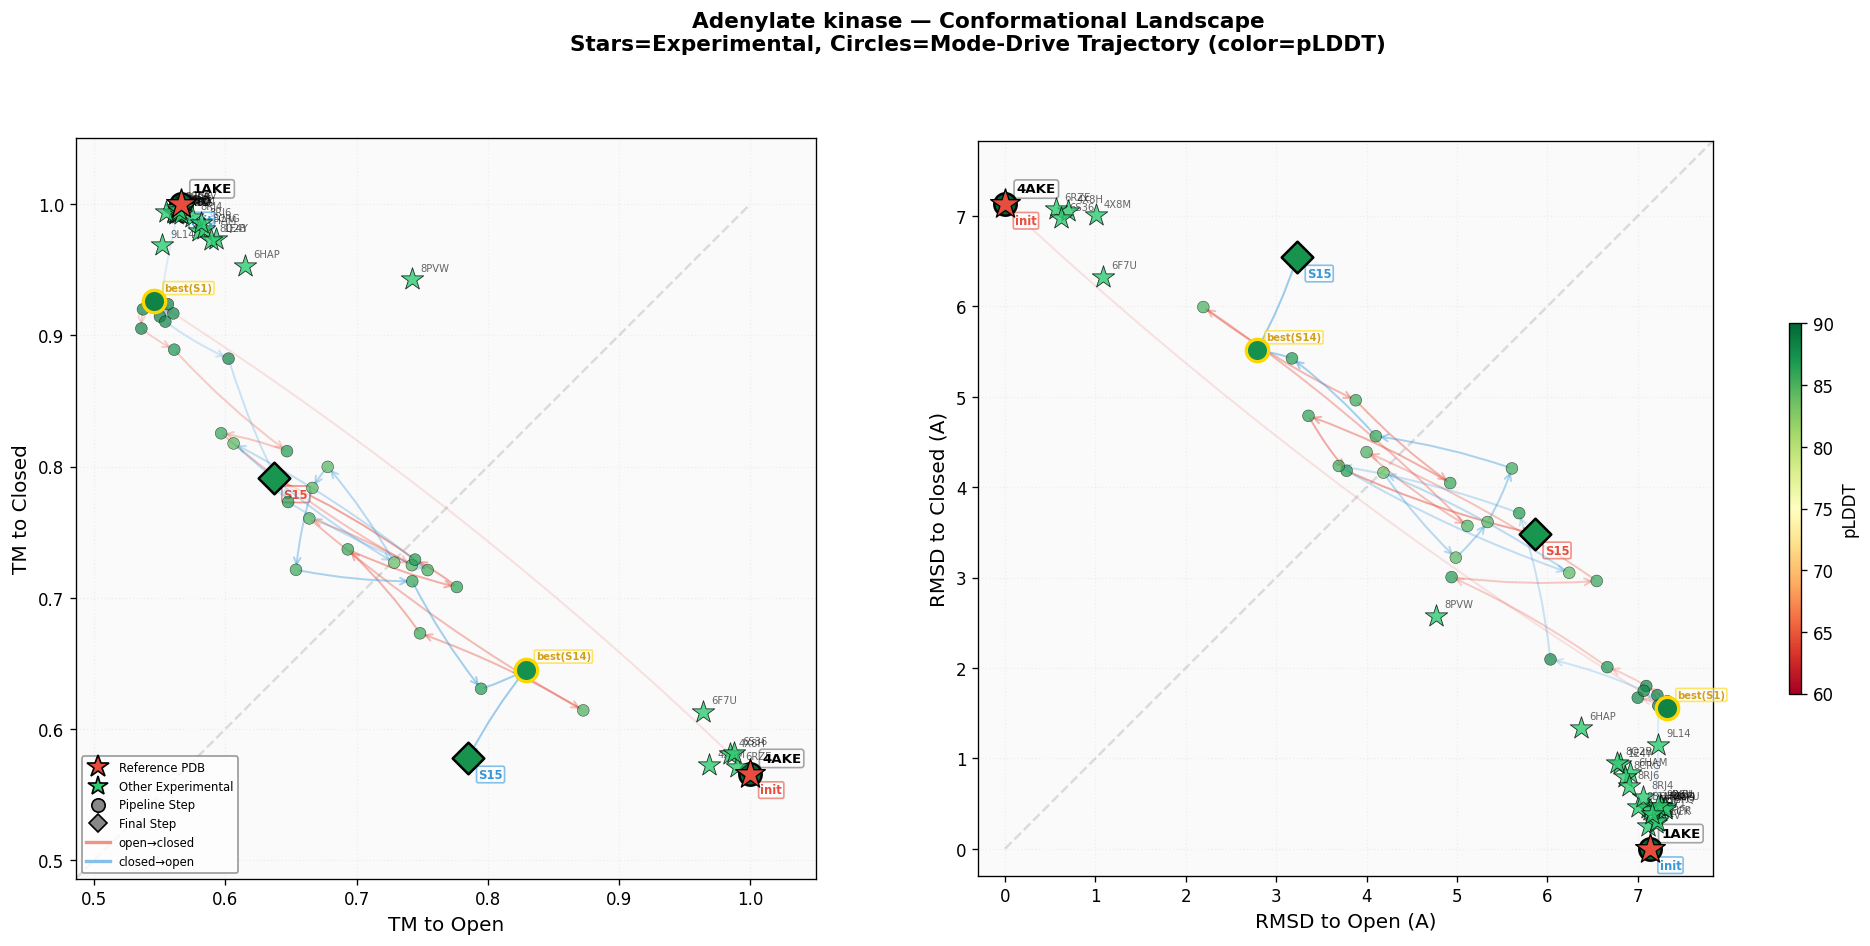

Saved: /content/drive/MyDrive/ANM-openfold3/benchmark/fig_landscape_Adenylate_kinase.png


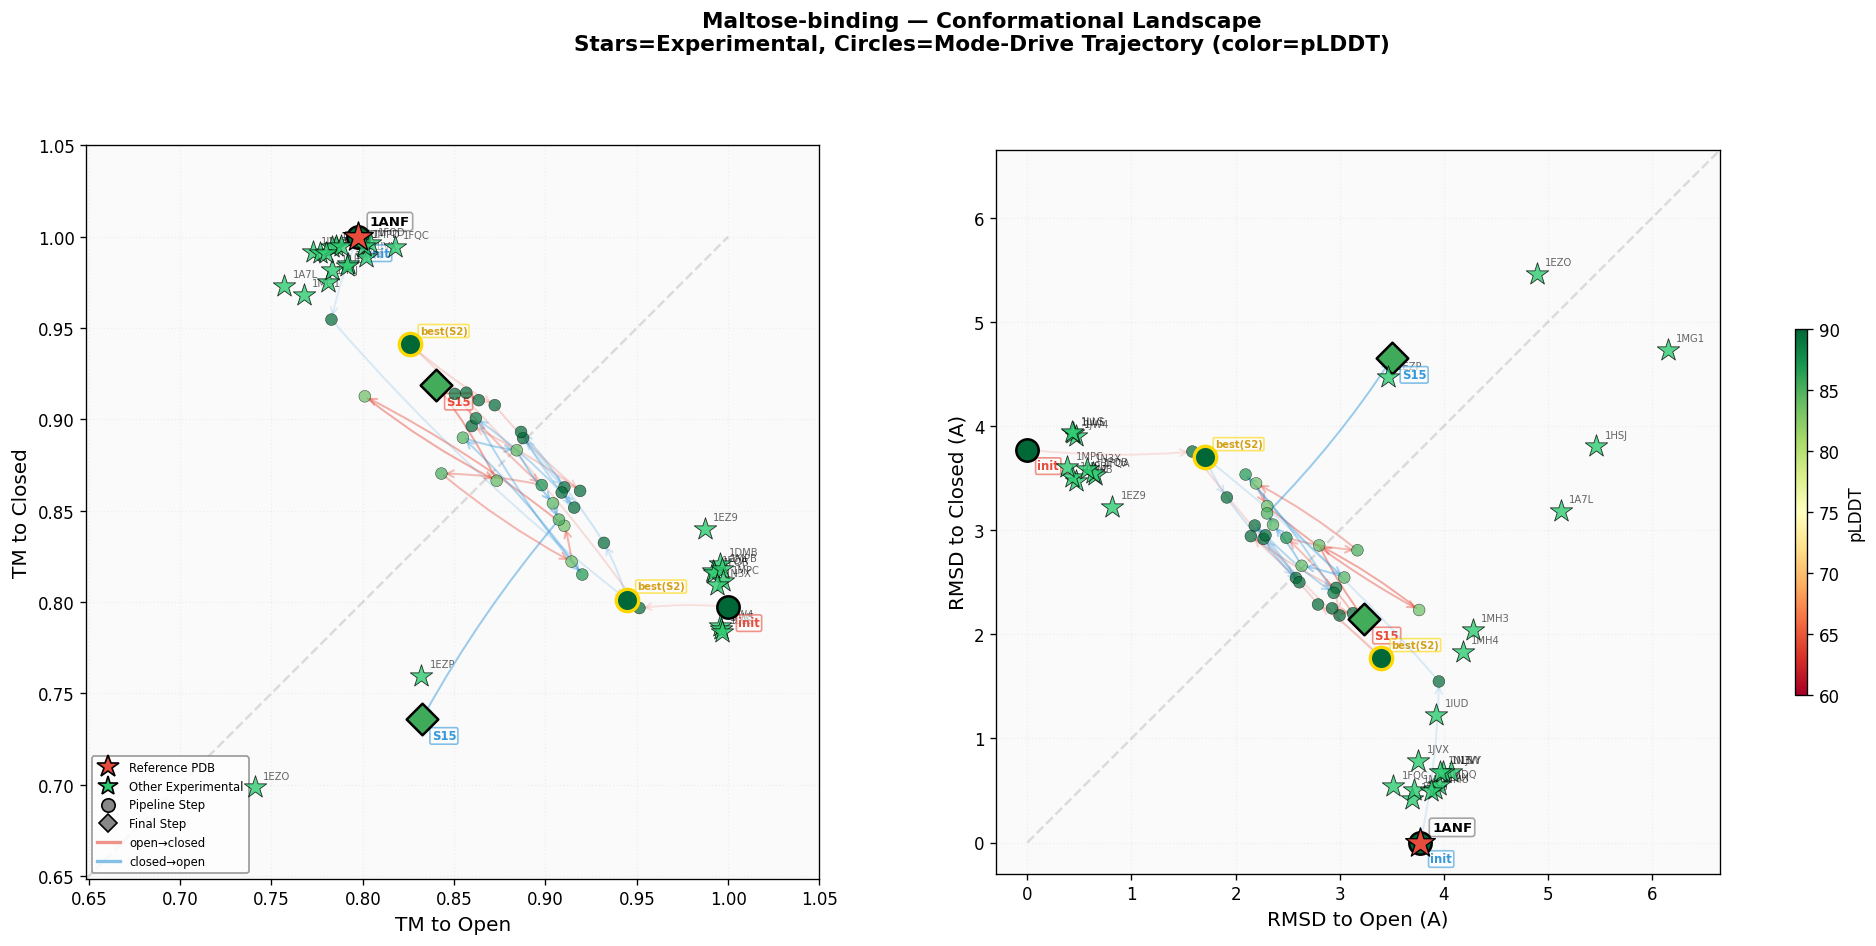

Saved: /content/drive/MyDrive/ANM-openfold3/benchmark/fig_landscape_Maltose-binding.png


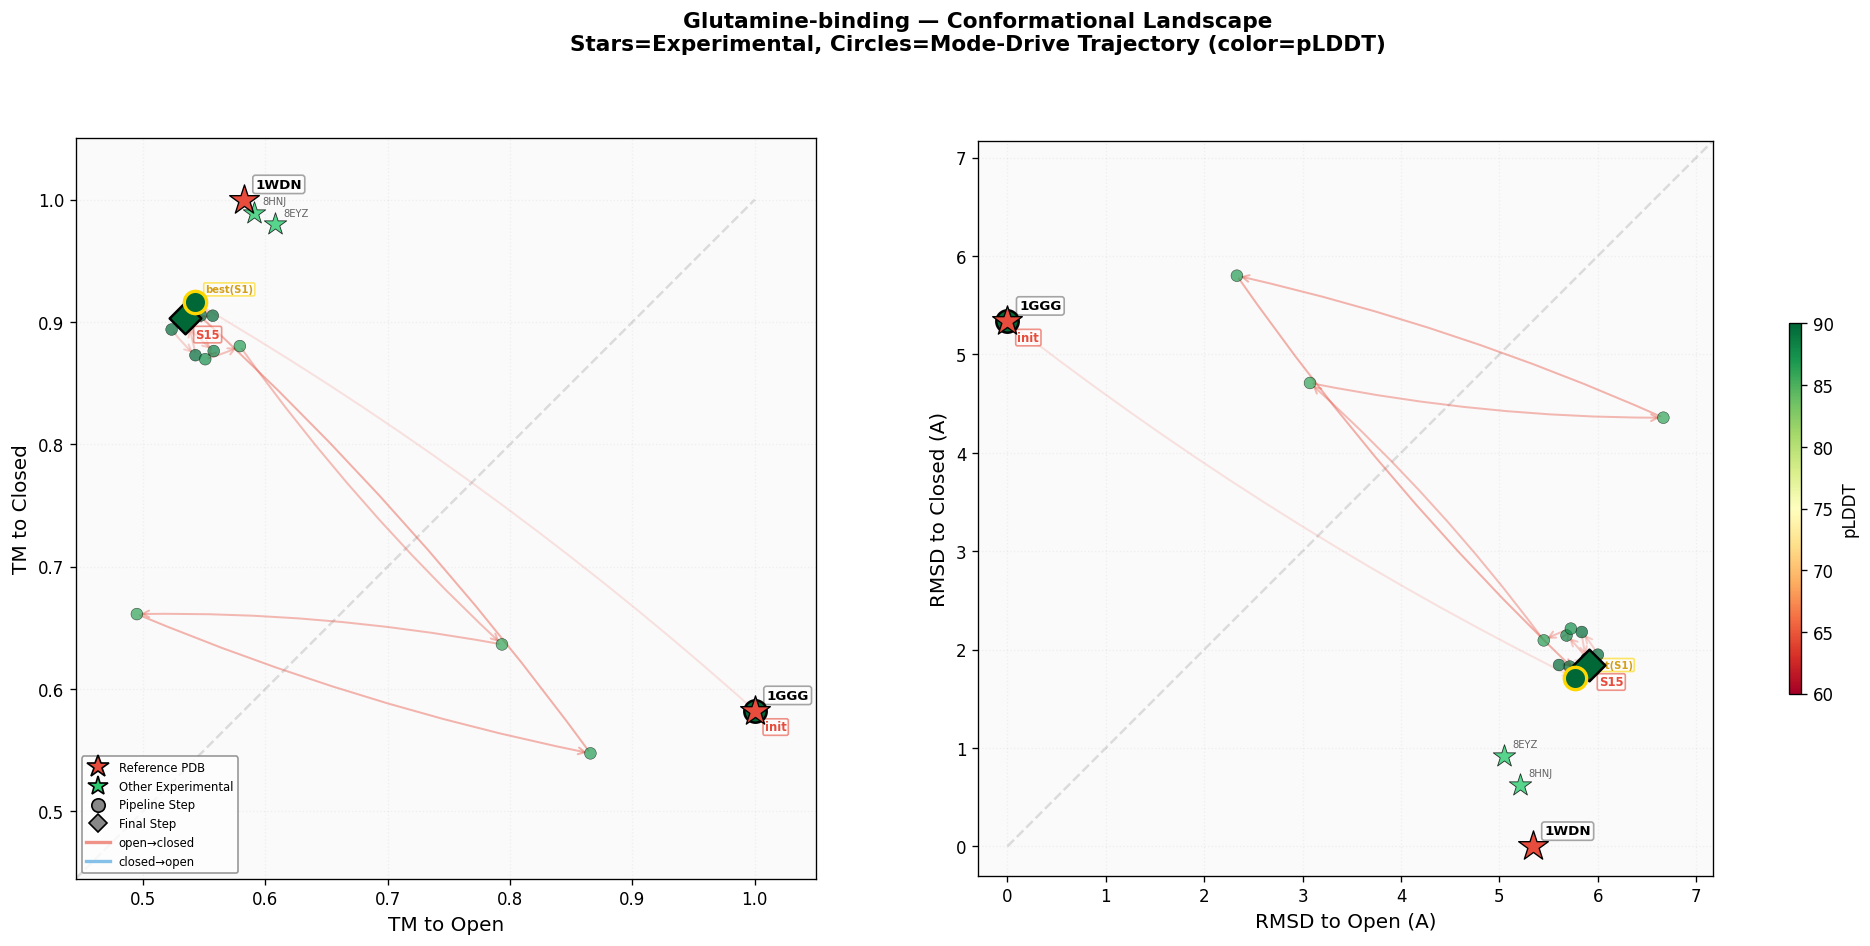

Saved: /content/drive/MyDrive/ANM-openfold3/benchmark/fig_landscape_Glutamine-binding.png


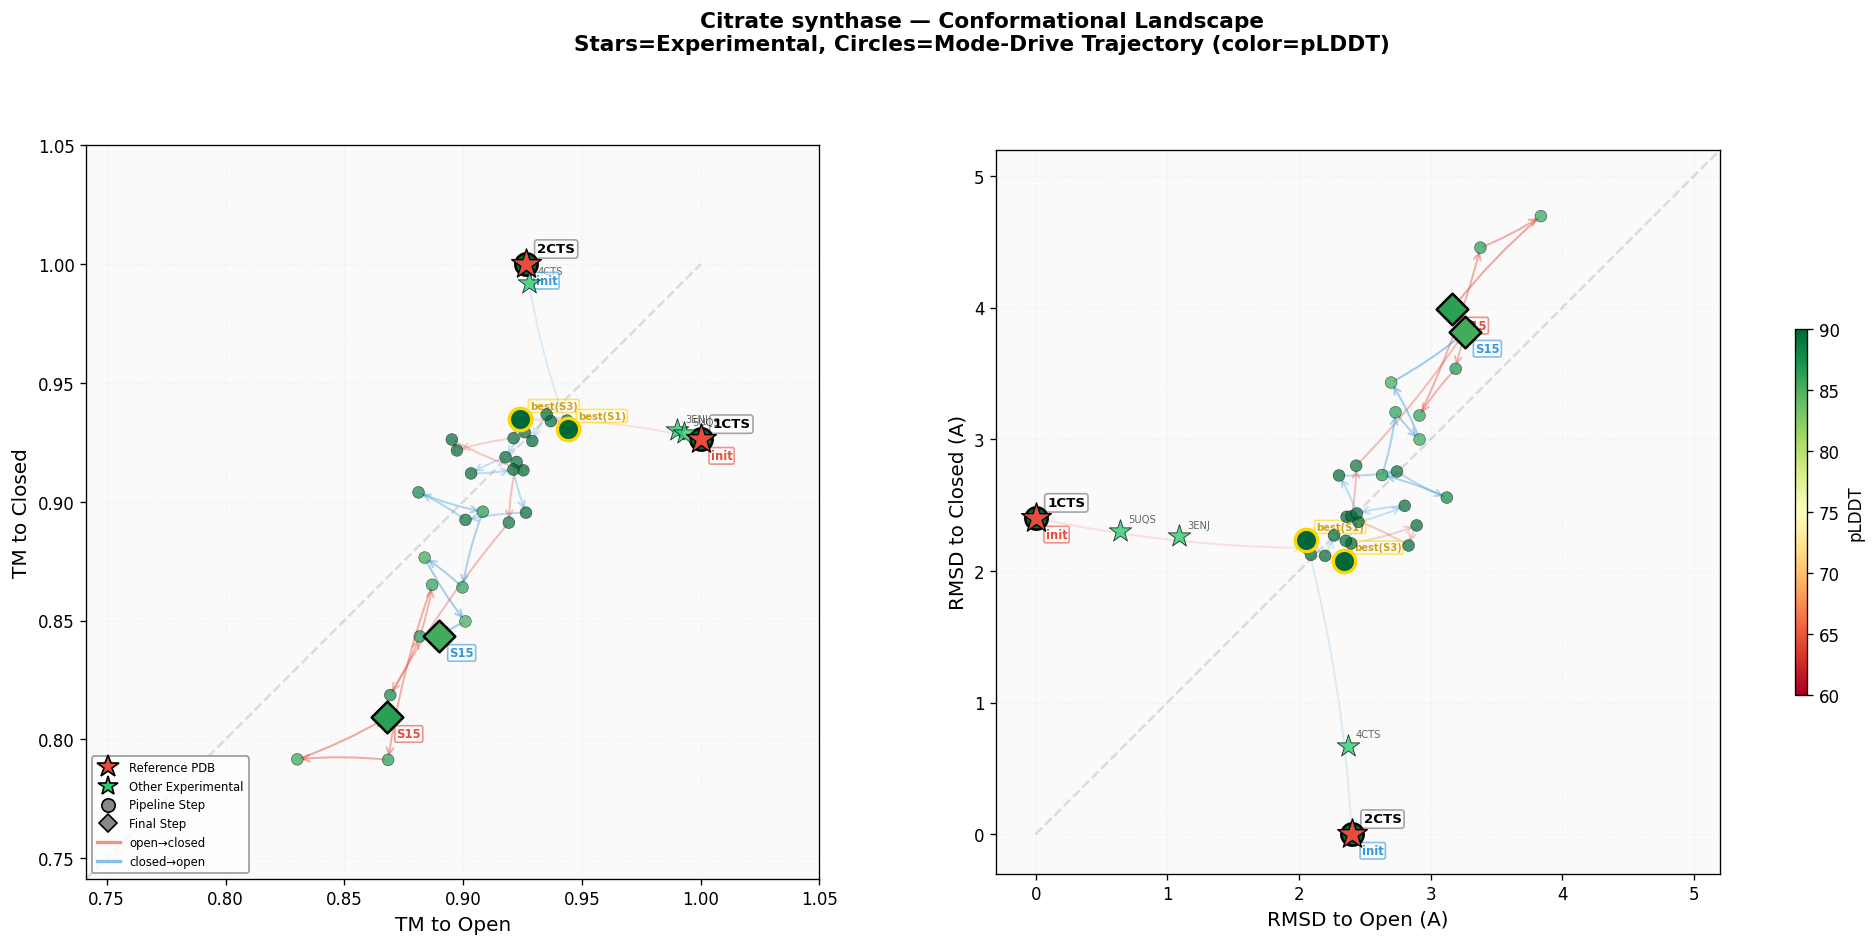

Saved: /content/drive/MyDrive/ANM-openfold3/benchmark/fig_landscape_Citrate_synthase.png


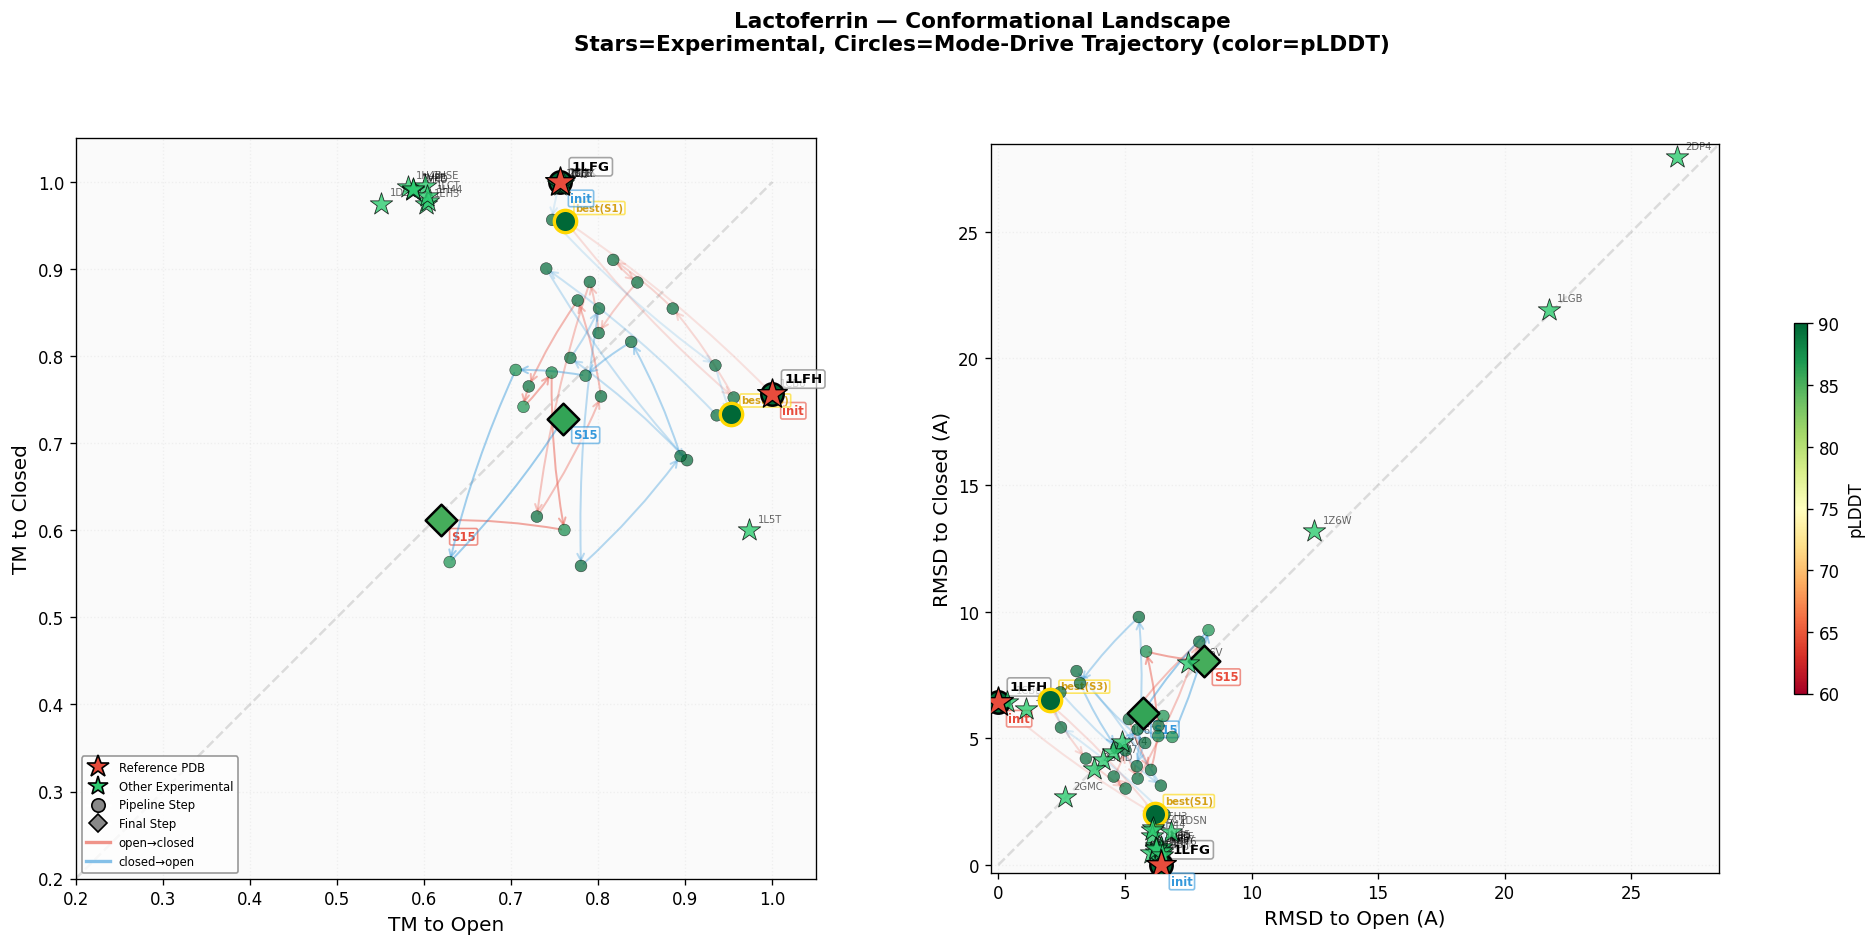

Saved: /content/drive/MyDrive/ANM-openfold3/benchmark/fig_landscape_Lactoferrin.png


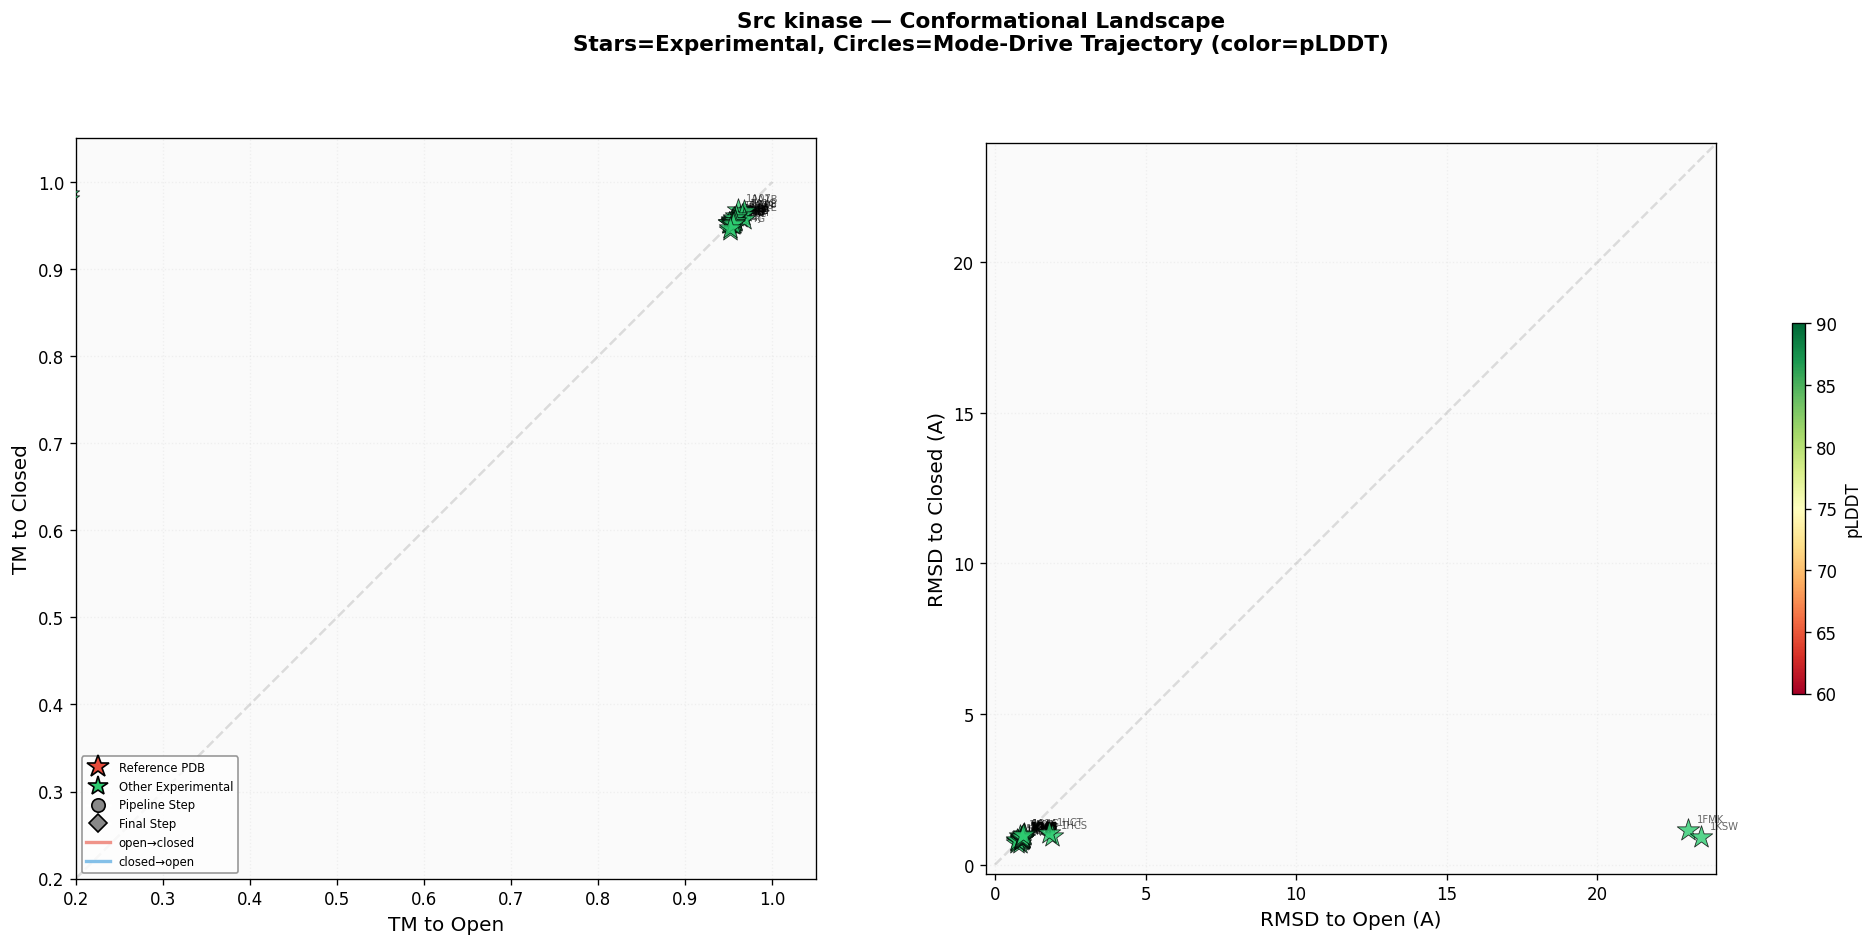

Saved: /content/drive/MyDrive/ANM-openfold3/benchmark/fig_landscape_Src_kinase.png


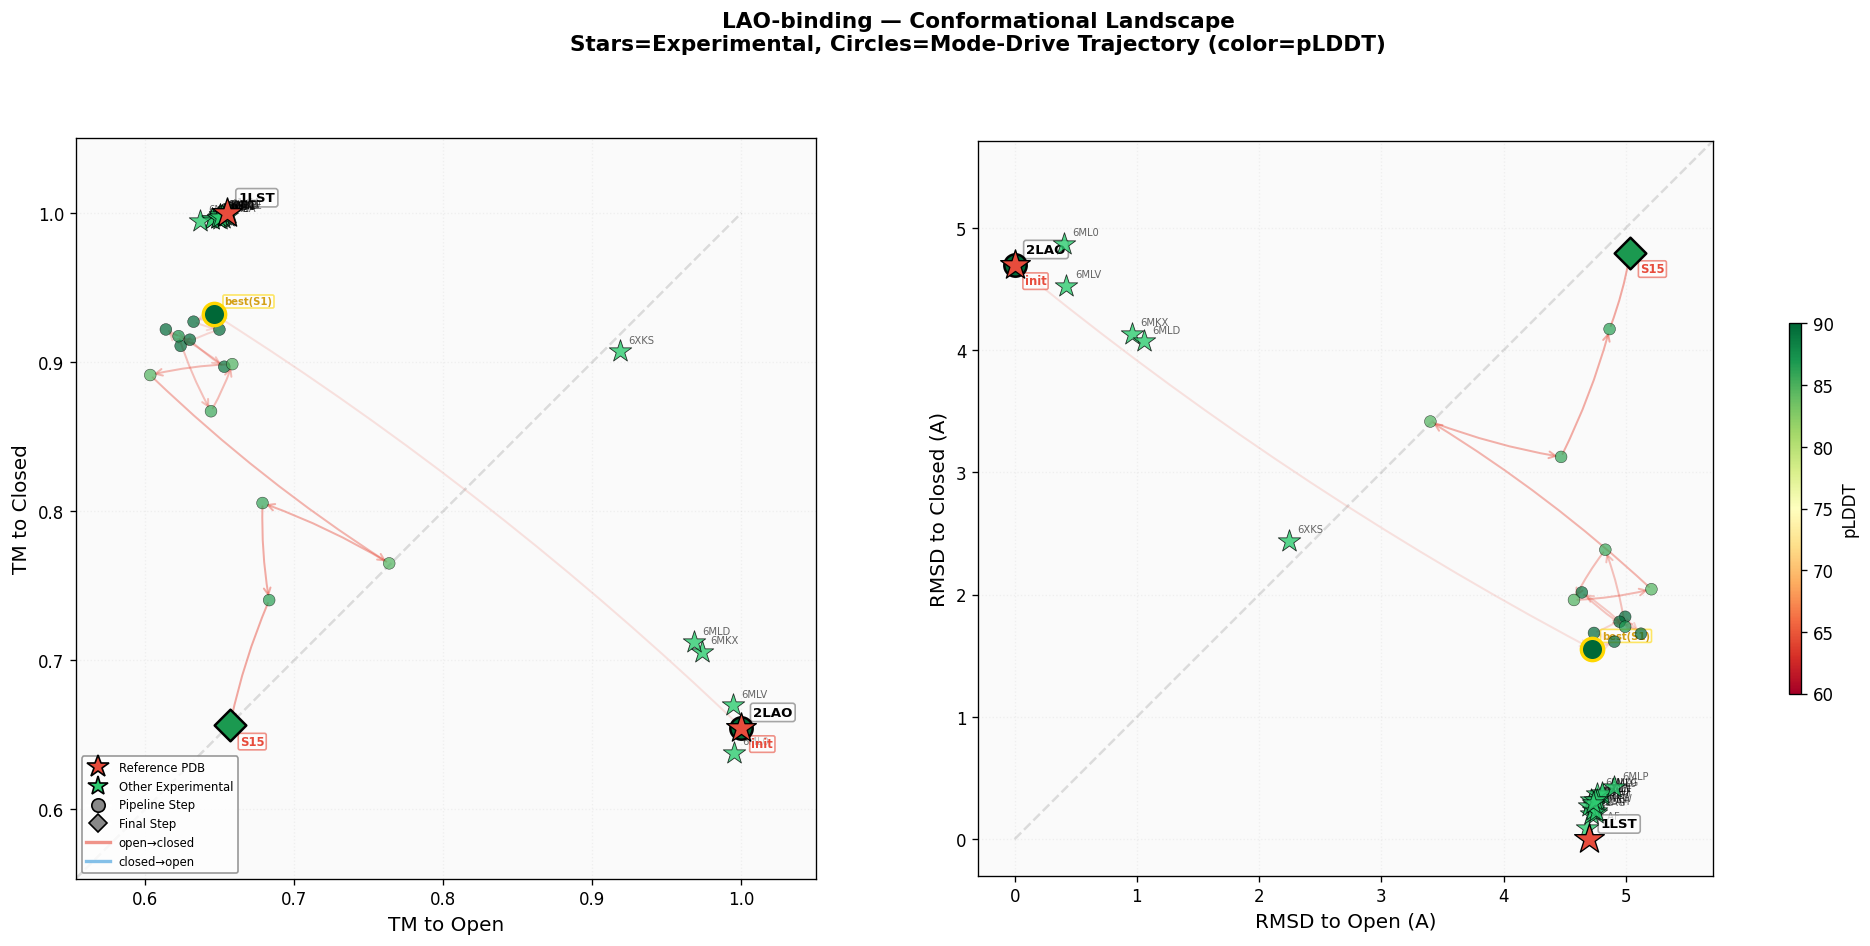

Saved: /content/drive/MyDrive/ANM-openfold3/benchmark/fig_landscape_LAO-binding.png


In [32]:
# ════════════════════════════════════════════════════════════════
#  PER-PROTEIN CONFORMATIONAL LANDSCAPE (mode_drive_explorer stili)
#  Her protein icin 2 panel:
#    Sol: TM to Open vs TM to Closed
#    Sag: RMSD to Open vs RMSD to Closed
#  Yildiz = experimental PDB, Daire = pipeline step (pLDDT renkli)
#  Ok ile trajectory yonu gosterilir
# ════════════════════════════════════════════════════════════════

import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch
from collections import defaultdict

if all_results and exp_conformations:
    protein_runs = defaultdict(list)
    for name, direction, dir_type, res in all_results:
        if dir_type in ('open->closed', 'closed->open'):
            protein_runs[name].append((direction, dir_type, res))

    proteins_with_data = [p for p in protein_runs if p in exp_conformations]

    for prot_name in proteins_with_data:
        runs = protein_runs[prot_name]
        exp_data = exp_conformations[prot_name]

        fig, axes = plt.subplots(1, 2, figsize=(18, 8))

        for panel_idx, metric_type in enumerate(['tm', 'rmsd']):
            ax = axes[panel_idx]

            # ── Experimental yapilar (yildiz) ──
            for entry in exp_data:
                if metric_type == 'tm':
                    xv, yv = entry['tm_to_open'], entry['tm_to_closed']
                else:
                    xv = entry.get('rmsd_to_open', None)
                    yv = entry.get('rmsd_to_closed', None)
                    if xv is None or yv is None:
                        continue

                if entry['is_reference']:
                    ax.scatter(xv, yv, marker='*', s=350, c='#e74c3c',
                              edgecolors='black', linewidths=0.8, zorder=20)
                    ax.annotate(entry['pdb_id'], (xv, yv),
                               textcoords='offset points', xytext=(7, 7),
                               fontsize=8, fontweight='bold',
                               bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='gray', alpha=0.7))
                else:
                    ax.scatter(xv, yv, marker='*', s=200, c='#2ecc71',
                              edgecolors='black', linewidths=0.5, zorder=15, alpha=0.8)
                    ax.annotate(entry['pdb_id'], (xv, yv),
                               textcoords='offset points', xytext=(5, 5),
                               fontsize=6, alpha=0.6)

            # ── Pipeline trajectory ──
            for direction, dir_type, res in runs:
                if metric_type == 'tm':
                    vals_tgt = res['step_tms_target']
                    vals_src = res.get('step_tms_source', [])
                else:
                    vals_tgt = res['step_rmsds_target']
                    vals_src = res.get('step_rmsds_source', [])

                if not vals_src or len(vals_src) < 2:
                    continue
                n_pts = min(len(vals_tgt), len(vals_src))

                if dir_type == 'open->closed':
                    x_vals = vals_src[:n_pts]
                    y_vals = vals_tgt[:n_pts]
                elif dir_type == 'closed->open':
                    x_vals = vals_tgt[:n_pts]
                    y_vals = vals_src[:n_pts]

                # pLDDT per step
                step_plddts = []
                acc_idx = 0
                for si in range(n_pts):
                    if si == 0:
                        step_plddts.append(90.0)
                        continue
                    metrics = res['step_metrics']
                    if acc_idx < len(metrics):
                        plddt = metrics[acc_idx].get('plddt_mean', None)
                        step_plddts.append(plddt if plddt is not None else 75.0)
                        acc_idx += 1
                    else:
                        step_plddts.append(75.0)

                line_color = '#e74c3c' if dir_type == 'open->closed' else '#3498db'

                # Trajectory cizgi: gradient alpha (baslangicta acik, sonda koyu)
                for si in range(n_pts - 1):
                    alpha = 0.15 + 0.35 * (si / max(n_pts - 1, 1))
                    ax.annotate('', xy=(x_vals[si+1], y_vals[si+1]),
                               xytext=(x_vals[si], y_vals[si]),
                               arrowprops=dict(arrowstyle='->', color=line_color,
                                             alpha=alpha, lw=1.2,
                                             connectionstyle='arc3,rad=0.05'))

                # Trajectory noktalar (pLDDT renkli)
                norm = plt.Normalize(60, 90)
                cmap = cm.get_cmap('RdYlGn')

                # Ara noktalar (kucuk)
                if n_pts > 2:
                    sc = ax.scatter(x_vals[1:-1], y_vals[1:-1],
                                  c=step_plddts[1:-1], cmap='RdYlGn', norm=norm,
                                  s=50, edgecolors='black', linewidths=0.3,
                                  zorder=8, alpha=0.7)

                # Init (buyuk, farkli marker)
                ax.scatter(x_vals[0], y_vals[0], c=[cmap(norm(step_plddts[0]))],
                          s=180, edgecolors='black', linewidths=1.5,
                          zorder=12, marker='o')
                ax.annotate('init', (x_vals[0], y_vals[0]),
                           textcoords='offset points', xytext=(6, -12),
                           fontsize=7, fontweight='bold', color=line_color,
                           bbox=dict(boxstyle='round,pad=0.15', fc='white', ec=line_color, alpha=0.6))

                # Final (buyuk, diamond)
                ax.scatter(x_vals[-1], y_vals[-1], c=[cmap(norm(step_plddts[-1]))],
                          s=180, edgecolors='black', linewidths=1.5,
                          zorder=12, marker='D')
                ax.annotate(f'S{n_pts-1}', (x_vals[-1], y_vals[-1]),
                           textcoords='offset points', xytext=(6, -12),
                           fontsize=7, fontweight='bold', color=line_color,
                           bbox=dict(boxstyle='round,pad=0.15', fc='white', ec=line_color, alpha=0.6))

                # Best step (en yuksek TM to target)
                if metric_type == 'tm':
                    best_idx = int(np.argmax(vals_tgt[:n_pts]))
                else:
                    best_idx = int(np.argmin(vals_tgt[:n_pts]))
                if best_idx not in (0, n_pts - 1):
                    ax.scatter(x_vals[best_idx], y_vals[best_idx],
                              c=[cmap(norm(step_plddts[best_idx]))],
                              s=180, edgecolors='gold', linewidths=2,
                              zorder=13, marker='o')
                    ax.annotate(f'best(S{best_idx})', (x_vals[best_idx], y_vals[best_idx]),
                               textcoords='offset points', xytext=(6, 6),
                               fontsize=6, fontweight='bold', color='#d4a017',
                               bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='gold', alpha=0.6))

            # Axis ayarlari
            if metric_type == 'tm':
                ax.set_xlabel('TM to Open', fontsize=12)
                ax.set_ylabel('TM to Closed', fontsize=12)
                # Dynamic TM limits
                all_tm_x, all_tm_y = [], []
                for entry in exp_data:
                    all_tm_x.append(entry['tm_to_open'])
                    all_tm_y.append(entry['tm_to_closed'])
                for _, dt, res in runs:
                    s = res.get('step_tms_source', [])
                    t = res['step_tms_target']
                    if dt == 'open->closed' and s:
                        all_tm_x.extend(s); all_tm_y.extend(t)
                    elif dt == 'closed->open' and s:
                        all_tm_x.extend(t); all_tm_y.extend(s)
                lo = max(0.2, min(all_tm_x + all_tm_y) - 0.05)
                ax.set_xlim(lo, 1.05); ax.set_ylim(lo, 1.05)
                ax.set_aspect('equal')
                ax.plot([lo, 1], [lo, 1], 'k--', alpha=0.12)
            else:
                ax.set_xlabel('RMSD to Open (A)', fontsize=12)
                ax.set_ylabel('RMSD to Closed (A)', fontsize=12)
                ax.set_aspect('equal')
                all_r = [0]
                for entry in exp_data:
                    ro, rc = entry.get('rmsd_to_open'), entry.get('rmsd_to_closed')
                    if ro: all_r.append(ro)
                    if rc: all_r.append(rc)
                for _, dt, res in runs:
                    all_r.extend(res['step_rmsds_target'])
                    all_r.extend(res.get('step_rmsds_source', []))
                mr = max(all_r) + 0.5
                ax.set_xlim(-0.3, mr); ax.set_ylim(-0.3, mr)
                ax.plot([0, mr], [0, mr], 'k--', alpha=0.12)

            ax.grid(True, alpha=0.15, linestyle=':')
            ax.set_facecolor('#fafafa')

        # Colorbar (sag kenarda)
        sm = cm.ScalarMappable(norm=plt.Normalize(60, 90), cmap='RdYlGn')
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=axes[-1], shrink=0.5, pad=0.08, aspect=30)
        cbar.set_label('pLDDT', fontsize=10)

        # Legend
        legend_el = [
            Line2D([0], [0], marker='*', color='w', markerfacecolor='#e74c3c',
                   markeredgecolor='black', markersize=14, label='Reference PDB'),
            Line2D([0], [0], marker='*', color='w', markerfacecolor='#2ecc71',
                   markeredgecolor='black', markersize=12, label='Other Experimental'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='#888',
                   markeredgecolor='black', markersize=8, label='Pipeline Step'),
            Line2D([0], [0], marker='D', color='w', markerfacecolor='#888',
                   markeredgecolor='black', markersize=8, label='Final Step'),
            Line2D([0], [0], color='#e74c3c', linewidth=2, alpha=0.6,
                   label='open\u2192closed'),
            Line2D([0], [0], color='#3498db', linewidth=2, alpha=0.6,
                   label='closed\u2192open'),
        ]
        axes[0].legend(handles=legend_el, loc='lower left', fontsize=7,
                      framealpha=0.8, edgecolor='gray')

        fig.suptitle(
            f'{prot_name} \u2014 Conformational Landscape\n'
            f'Stars=Experimental, Circles=Mode-Drive Trajectory (color=pLDDT)',
            fontsize=13, fontweight='bold'
        )
        plt.tight_layout(rect=[0, 0, 0.95, 0.93])
        p = os.path.join(BASE_SAVE_DIR, f'fig_landscape_{prot_name.replace(" ", "_")}.png')
        fig.savefig(p, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'Saved: {p}')
